# Final Error Analysis and Production Retrain

## Objective

Notebook này thực hiện final error analysis và production retraining.

Notebook 14 đã hoàn thành holdout evaluation bằng model fit trên training split 80%. Điều này cần thiết để giữ 20% holdout set cho đánh giá công bằng.

Notebook này sử dụng holdout predictions từ notebook 14 để phân tích model sai ở đâu và vì sao sai. Sau khi error analysis hoàn tất, notebook sẽ retrain cấu hình model cuối cùng trên 100% dữ liệu labeled để tạo production model thật cho web/backend.

Production model cuối cùng sẽ được lưu vào:

`models/final_laptop_price_model.joblib`

kèm metadata và feature schema.

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime

from sklearn.base import clone
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
    max_error,
)

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

current_path = Path.cwd().resolve()
if (current_path / "data" / "processed" / "final_dataset.csv").exists():
    PROJECT_ROOT = current_path
elif current_path.name == "modeling" and current_path.parent.name == "notebooks":
    PROJECT_ROOT = current_path.parents[1]
elif current_path.name.lower() in ["notebooks", "notebook"]:
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"
NOTEBOOK_DIR = current_path

PRODUCTION_MODEL_DIR = PROJECT_ROOT / "models"

TUNING_DIR = PROJECT_ROOT / "artifacts" / "hyperparameter_tuning"
TUNING_MODEL_DIR = TUNING_DIR / "models"
TUNING_PARAM_DIR = TUNING_DIR / "params"

EVAL_DIR = PROJECT_ROOT / "artifacts" / "final_model_evaluation"
EVAL_METRIC_DIR = EVAL_DIR / "metrics"
EVAL_PRED_DIR = EVAL_DIR / "predictions"
EVAL_REPORT_DIR = EVAL_DIR / "reports"
EVAL_MODEL_DIR = EVAL_DIR / "models"

ERROR_DIR = PROJECT_ROOT / "artifacts" / "final_error_analysis"
ERROR_METRIC_DIR = ERROR_DIR / "metrics"
ERROR_REPORT_DIR = ERROR_DIR / "reports"
ERROR_PLOT_DIR = ERROR_DIR / "plots"
ERROR_PRED_DIR = ERROR_DIR / "predictions"

ERROR_ANALYSIS_REPORT_DIR = PROJECT_ROOT / "reports" / "error_analysis"

for d in [
    PRODUCTION_MODEL_DIR,
    ERROR_METRIC_DIR,
    ERROR_REPORT_DIR,
    ERROR_PLOT_DIR,
    ERROR_PRED_DIR,
    ERROR_ANALYSIS_REPORT_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"Production model directory: {PRODUCTION_MODEL_DIR}")
print(f"Error analysis directory: {ERROR_DIR}")
print(f"Error analysis report directory: {ERROR_ANALYSIS_REPORT_DIR}")

# ── Report artifact mirroring ─────────────────────────────────────────────────
# Keep the original artifact paths for downstream notebooks, and mirror every
# generated table/figure into reports/tables and reports/figures for the report.
NOTEBOOK_SLUG = "15_final_error_analysis_and_production_retrain"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_FIGURES_DIR = REPORT_DIR / "figures" / NOTEBOOK_SLUG
REPORT_TABLES_DIR = REPORT_DIR / "tables" / NOTEBOOK_SLUG
for directory in [REPORT_FIGURES_DIR, REPORT_TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def _report_relative_path(path):
    path = Path(path)
    try:
        path = path.resolve()
    except OSError:
        path = path.absolute()
    for base in [PROJECT_ROOT / "artifacts", PROJECT_ROOT / "reports", PROJECT_ROOT]:
        try:
            return path.relative_to(base.resolve())
        except ValueError:
            continue
    return Path(path.name)


def _mirror_report_artifact(path, destination_root):
    if path is None or destination_root is None or not isinstance(path, (str, Path)):
        return
    src = Path(path)
    if not src.exists() or not src.is_file():
        return
    rel = _report_relative_path(src)
    dst = destination_root / rel
    try:
        if src.resolve() == dst.resolve():
            return
    except OSError:
        pass
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)


import shutil
from matplotlib.figure import Figure

if not hasattr(pd.DataFrame, "_reports_original_to_csv"):
    pd.DataFrame._reports_original_to_csv = pd.DataFrame.to_csv
if not hasattr(pd.Series, "_reports_original_to_csv"):
    pd.Series._reports_original_to_csv = pd.Series.to_csv
if not hasattr(pd.DataFrame, "_reports_original_to_excel"):
    pd.DataFrame._reports_original_to_excel = pd.DataFrame.to_excel
if not hasattr(Figure, "_reports_original_savefig"):
    Figure._reports_original_savefig = Figure.savefig


def _to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _series_to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.Series._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _to_excel_with_report_mirror(self, excel_writer, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_excel(self, excel_writer, *args, **kwargs)
    _mirror_report_artifact(excel_writer, globals().get("REPORT_TABLES_DIR"))
    return result


def _savefig_with_report_mirror(self, fname, *args, **kwargs):
    result = Figure._reports_original_savefig(self, fname, *args, **kwargs)
    _mirror_report_artifact(fname, globals().get("REPORT_FIGURES_DIR"))
    return result


_to_csv_with_report_mirror._reports_mirror_patch = True
_series_to_csv_with_report_mirror._reports_mirror_patch = True
_to_excel_with_report_mirror._reports_mirror_patch = True
_savefig_with_report_mirror._reports_mirror_patch = True
pd.DataFrame.to_csv = _to_csv_with_report_mirror
pd.Series.to_csv = _series_to_csv_with_report_mirror
pd.DataFrame.to_excel = _to_excel_with_report_mirror
Figure.savefig = _savefig_with_report_mirror

print(f"Report figures mirrored to: {REPORT_FIGURES_DIR}")
print(f"Report tables mirrored to : {REPORT_TABLES_DIR}")


Project root: Y:\Python\Laptop-Price-Prediction
Data path: Y:\Python\Laptop-Price-Prediction\data\processed\final_dataset.csv
Production model directory: Y:\Python\Laptop-Price-Prediction\models
Error analysis directory: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis
Error analysis report directory: Y:\Python\Laptop-Price-Prediction\reports\error_analysis
Report figures mirrored to: Y:\Python\Laptop-Price-Prediction\reports\figures\15_final_error_analysis_and_production_retrain
Report tables mirrored to : Y:\Python\Laptop-Price-Prediction\reports\tables\15_final_error_analysis_and_production_retrain


## Load Final Dataset

In [3]:
df = pd.read_csv(DATA_PATH)

TARGET_COL = "target_price"
DROP_TARGET_COLS = ["target_price", "log_target_price"]

if TARGET_COL not in df.columns:
    raise ValueError(f"Missing target column: {TARGET_COL}")

X = df.drop(
    columns=[c for c in DROP_TARGET_COLS if c in df.columns],
    errors="ignore",
)

X = X.select_dtypes(include=[np.number]).copy()
y = df[TARGET_COL].copy()

feature_names = X.columns.tolist()

if X.empty:
    raise ValueError("Feature matrix is empty after selecting numeric features.")

print("Dataset shape:", df.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", len(feature_names))

Dataset shape: (7296, 88)
Feature matrix shape: (7296, 86)
Target shape: (7296,)
Number of features: 86


## Recreate Holdout Split for Error Context Only

Notebook này tái tạo holdout split giống notebook 14 để merge context và phân tích lỗi.

Holdout set ở đây không dùng để chọn model lại. Model decision đã được đưa ra ở notebook 14. Phần này chỉ phục vụ error analysis.

In [4]:
price_segment_holdout = pd.qcut(
    y,
    q=5,
    labels=False,
    duplicates="drop",
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=price_segment_holdout,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5836, 86)
Test shape: (1460, 86)


## Load Notebook 14 Final Decision

In [5]:
final_decision_path = EVAL_REPORT_DIR / "final_model_decision.json"

if not final_decision_path.exists():
    raise FileNotFoundError(f"Missing final decision file: {final_decision_path}")

with open(final_decision_path, "r", encoding="utf-8") as f:
    final_decision = json.load(f)

required_decision_keys = [
    "recommended_final_model",
    "kfold_selected_model",
    "best_holdout_model",
    "decision_status",
    "decision_reason",
]

for key in required_decision_keys:
    if key not in final_decision:
        raise ValueError(f"Missing key in final decision: {key}")

recommended_model_label = final_decision["recommended_final_model"]

print("Recommended final model:", recommended_model_label)
final_decision

Recommended final model: CatBoost_tuned


{'kfold_selected_model': 'CatBoost_tuned',
 'best_holdout_model': 'LightGBM_baseline',
 'recommended_final_model': 'CatBoost_tuned',
 'decision_status': 'keep_kfold_selected_model',
 'decision_reason': 'Selected model is not best on holdout RMSE, but the gap is within tolerance. Keep KFold-selected model because it is more stable across folds.',
 'holdout_rmse_tolerance_pct': 3.0,
 'selected_holdout_rmse': 5.912733148042646,
 'best_holdout_rmse': 5.7848789171213095,
 'rmse_gap_pct': 2.210145324613979}

## Load Holdout Predictions

In [6]:
holdout_pred_path = EVAL_PRED_DIR / "final_holdout_predictions.csv"

if not holdout_pred_path.exists():
    raise FileNotFoundError(f"Missing holdout prediction file: {holdout_pred_path}")

final_predictions_df = pd.read_csv(holdout_pred_path)

required_pred_cols = [
    "sample_index",
    "actual_price",
    "predicted_price",
    "residual",
    "abs_error",
    "ape_pct",
    "model_label",
]

for col in required_pred_cols:
    if col not in final_predictions_df.columns:
        raise ValueError(f"Missing prediction column: {col}")

model_pred_df = final_predictions_df[
    final_predictions_df["model_label"] == recommended_model_label
].copy()

if model_pred_df.empty:
    raise ValueError(
        f"No predictions found for recommended model: {recommended_model_label}"
    )

model_pred_df["sample_index"] = model_pred_df["sample_index"].astype(int)

display(model_pred_df.head())
print("Holdout prediction rows for recommended model:", model_pred_df.shape)

,sample_index,actual_price,predicted_price,residual,abs_error,ape_pct,model_label
4380,2529,5.80,7.427820,-1.627820,1.627820,28.065865,CatBoost_tuned
4381,4044,5.00,4.752886,0.247114,0.247114,4.942273,CatBoost_tuned
4382,3208,6.70,8.626377,-1.926377,1.926377,28.751891,CatBoost_tuned
4383,7104,26.89,22.181917,4.708083,4.708083,17.508677,CatBoost_tuned
4384,6154,22.98,34.956373,-11.976373,11.976373,52.116507,CatBoost_tuned


Holdout prediction rows for recommended model: (1460, 7)


## Merge Raw Context into Prediction Errors

In [7]:
context_cols = [
    c for c in [
        "brand",
        "model",
        "name",
        "cpu_brand",
        "gpu_brand",
        "ram_gb",
        "storage_gb",
        "condition_score",
        "warranty_encoded",
        "screen_size",
        "screen_size_inch",
        "cpu_model",
        "gpu_model",
    ]
    if c in df.columns
]

error_context_df = model_pred_df.merge(
    df[context_cols],
    left_on="sample_index",
    right_index=True,
    how="left",
)

display(error_context_df.head())

error_context_df.to_csv(
    ERROR_PRED_DIR / "final_model_holdout_errors_with_context.csv",
    index=False,
)

,sample_index,actual_price,predicted_price,residual,abs_error,ape_pct,model_label,ram_gb,storage_gb,condition_score,screen_size_inch
4380,2529,5.80,7.427820,-1.627820,1.627820,28.065865,CatBoost_tuned,16.0,256.0,2,13.95
4381,4044,5.00,4.752886,0.247114,0.247114,4.942273,CatBoost_tuned,0.0,0.0,2,0.00
4382,3208,6.70,8.626377,-1.926377,1.926377,28.751891,CatBoost_tuned,16.0,256.0,2,0.00
4383,7104,26.89,22.181917,4.708083,4.708083,17.508677,CatBoost_tuned,8.0,512.0,3,15.60
4384,6154,22.98,34.956373,-11.976373,11.976373,52.116507,CatBoost_tuned,16.0,0.0,3,0.00


## Error Overview

Residual is defined as:

`actual_price - predicted_price`

- Positive residual means the model underpredicted the price.
- Negative residual means the model overpredicted the price.

In [8]:
error_overview = {
    "model_label": recommended_model_label,
    "n_samples": len(error_context_df),
    "mae": error_context_df["abs_error"].mean(),
    "rmse": np.sqrt(np.mean(np.square(error_context_df["residual"]))),
    "median_ae": error_context_df["abs_error"].median(),
    "mape_pct": error_context_df["ape_pct"].mean(),
    "max_abs_error": error_context_df["abs_error"].max(),
    "mean_residual": error_context_df["residual"].mean(),
    "median_residual": error_context_df["residual"].median(),
    "underprediction_count": int((error_context_df["residual"] > 0).sum()),
    "overprediction_count": int((error_context_df["residual"] < 0).sum()),
}

error_overview_df = pd.DataFrame([error_overview])
display(error_overview_df)

error_overview_df.to_csv(
    ERROR_METRIC_DIR / "final_model_error_overview.csv",
    index=False,
)

,model_label,n_samples,mae,rmse,median_ae,mape_pct,max_abs_error,mean_residual,median_residual,underprediction_count,overprediction_count
0,CatBoost_tuned,1460,3.372626,5.912733,1.942894,32.254016,56.171322,-0.064396,-0.24896,665,795


## Top Error Cases

In [9]:
TOP_N = 30

top_error_cases_df = (
    error_context_df
    .sort_values("abs_error", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

display(top_error_cases_df)

top_error_cases_df.to_csv(
    ERROR_PRED_DIR / "top_final_error_cases.csv",
    index=False,
)

,sample_index,actual_price,predicted_price,residual,abs_error,ape_pct,model_label,ram_gb,storage_gb,condition_score,screen_size_inch
0,5913,62.000,118.171322,-56.171322,56.171322,90.598906,CatBoost_tuned,64.0,2048.0,3,16.00
1,6739,76.900,24.710545,52.189455,52.189455,67.866651,CatBoost_tuned,16.0,512.0,3,15.60
2,7187,50.999,98.310875,-47.311875,47.311875,92.770201,CatBoost_tuned,32.0,2048.0,3,17.00
3,6262,110.990,71.045667,39.944333,39.944333,35.989128,CatBoost_tuned,128.0,512.0,3,14.00
4,5661,63.050,98.220763,-35.170763,35.170763,55.782336,CatBoost_tuned,32.0,2048.0,3,17.30
5,5967,153.290,118.129405,35.160595,35.160595,22.937305,CatBoost_tuned,64.0,6144.0,3,18.00
6,7056,86.990,121.517049,-34.527049,34.527049,39.690825,CatBoost_tuned,64.0,2048.0,3,16.00
7,6501,58.899,26.890328,32.008672,32.008672,54.345017,CatBoost_tuned,16.0,512.0,3,14.00
8,5786,35.900,67.423989,-31.523989,31.523989,87.810554,CatBoost_tuned,32.0,0.0,3,16.00
9,7029,73.990,43.004582,30.985418,30.985418,41.877846,CatBoost_tuned,32.0,1024.0,3,16.00


## Actual vs Predicted Error Dispersion by RAM and Storage

Section này trực quan hóa sai lệch giữa actual price và predicted price theo `ram_gb` và `storage_gb`.

Các biểu đồ dùng holdout predictions của model final từ notebook 14. Chúng chỉ dùng để audit lỗi, không dùng để chọn lại model.

Tolerance plots bên dưới chỉ vẽ các điểm có absolute percentage error lớn hơn ngưỡng 5%, 10%, hoặc 15%. Những điểm nằm trong ngưỡng chấp nhận được sẽ bị ẩn để tập trung vào các case sai lệch đáng kiểm tra.

In [10]:
plot_required_cols = ["actual_price", "predicted_price", "residual", "abs_error", "ape_pct"]
missing_plot_required_cols = [c for c in plot_required_cols if c not in error_context_df.columns]

if missing_plot_required_cols:
    raise ValueError(f"Missing required plotting columns: {missing_plot_required_cols}")

ram_col = "ram_gb" if "ram_gb" in error_context_df.columns else None
storage_col = "storage_gb" if "storage_gb" in error_context_df.columns else None

print("RAM column for plots:", ram_col)
print("Storage column for plots:", storage_col)

if ram_col is None or storage_col is None:
    print(
        "Warning: RAM/storage plot columns are not fully available. "
        "Some plots will be skipped instead of failing the notebook."
    )

RAM column for plots: ram_gb
Storage column for plots: storage_gb


In [11]:
def add_identity_line(ax, values):
    finite_values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    if finite_values.empty:
        return
    min_value = finite_values.min()
    max_value = finite_values.max()
    ax.plot([min_value, max_value], [min_value, max_value], "--", color="black", linewidth=1, alpha=0.7)


def save_actual_predicted_scatter_by_color(df_plot, color_col, filename, title, tolerance_pct=None):
    if color_col is None or color_col not in df_plot.columns:
        print(f"Skipped plot {filename}: missing color column {color_col}")
        return None

    plot_df = df_plot.copy()
    if tolerance_pct is not None:
        plot_df = plot_df[plot_df["ape_pct"] > tolerance_pct].copy()

    if plot_df.empty:
        print(f"Skipped plot {filename}: no rows after tolerance filter")
        return None

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(
        plot_df["actual_price"],
        plot_df["predicted_price"],
        c=plot_df[color_col],
        cmap="viridis",
        alpha=0.75,
        edgecolors="none",
    )

    add_identity_line(ax, pd.concat([plot_df["actual_price"], plot_df["predicted_price"]]))
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label(color_col)

    ax.set_title(title)
    ax.set_xlabel("Actual price")
    ax.set_ylabel("Predicted price")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    path = ERROR_PLOT_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to: {path}")
    return path


def save_residual_scatter_by_feature(df_plot, x_col, color_col, filename, title, tolerance_pct=None):
    if x_col is None or x_col not in df_plot.columns:
        print(f"Skipped plot {filename}: missing x column {x_col}")
        return None

    plot_df = df_plot.copy()
    if tolerance_pct is not None:
        plot_df = plot_df[plot_df["ape_pct"] > tolerance_pct].copy()

    if plot_df.empty:
        print(f"Skipped plot {filename}: no rows after tolerance filter")
        return None

    fig, ax = plt.subplots(figsize=(8, 5))

    if color_col is not None and color_col in plot_df.columns:
        scatter = ax.scatter(
            plot_df[x_col],
            plot_df["residual"],
            c=plot_df[color_col],
            cmap="plasma",
            alpha=0.75,
            edgecolors="none",
        )
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label(color_col)
    else:
        ax.scatter(
            plot_df[x_col],
            plot_df["residual"],
            alpha=0.75,
            edgecolors="none",
        )

    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel("Residual = actual - predicted")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    path = ERROR_PLOT_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to: {path}")
    return path

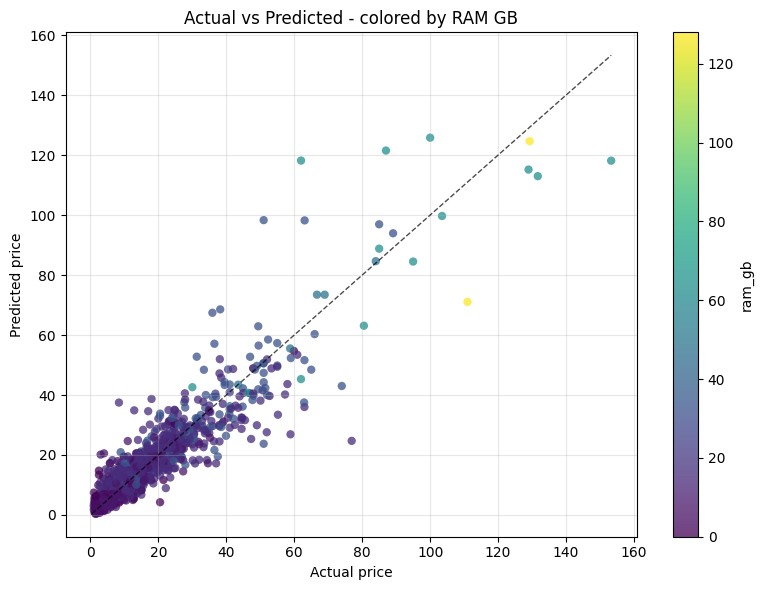

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\actual_vs_predicted_colored_by_ram_gb.png


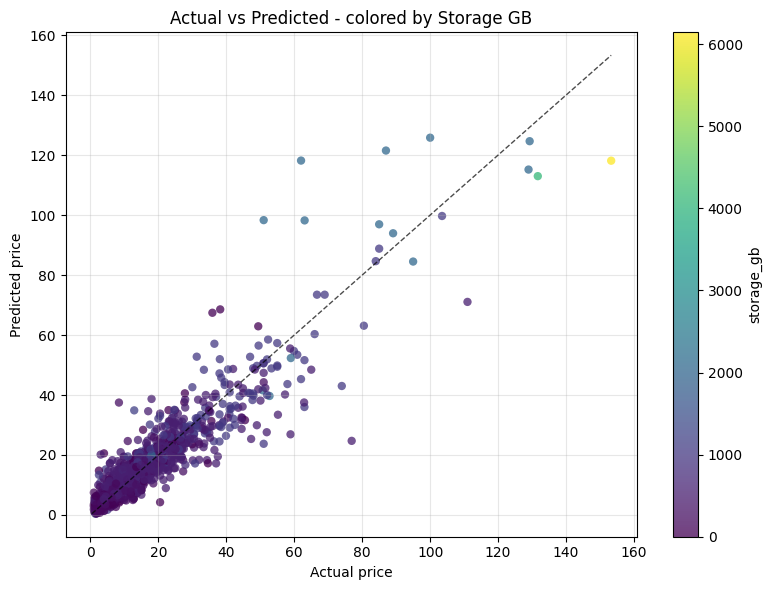

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\actual_vs_predicted_colored_by_storage_gb.png


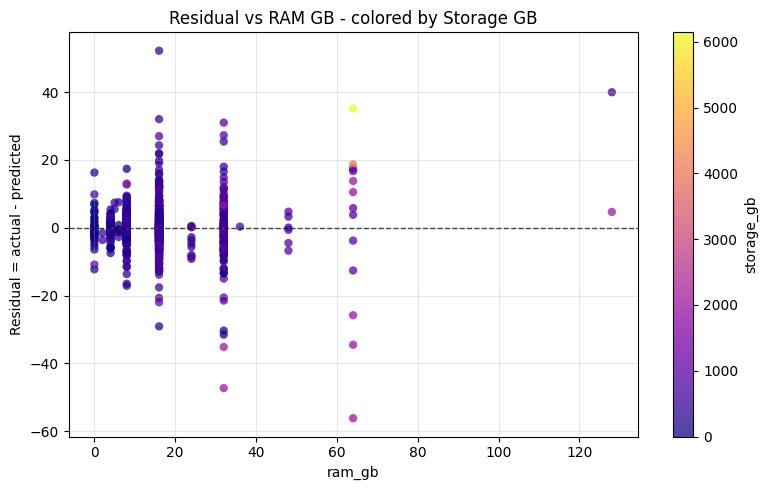

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\residual_vs_ram_gb_colored_by_storage_gb.png


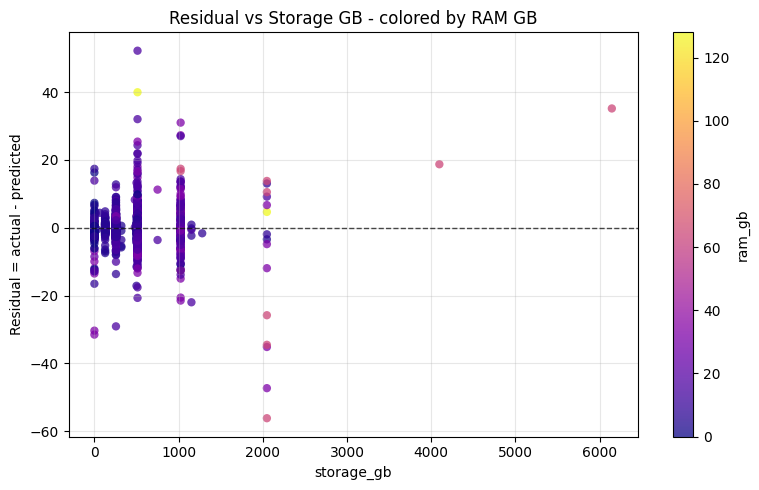

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\residual_vs_storage_gb_colored_by_ram_gb.png
RAM/storage diagnostic plots created: 4


In [12]:
ram_storage_plot_paths = []

base_plot_specs = [
    (
        save_actual_predicted_scatter_by_color,
        {"color_col": ram_col, "filename": "actual_vs_predicted_colored_by_ram_gb.png", "title": "Actual vs Predicted - colored by RAM GB"},
    ),
    (
        save_actual_predicted_scatter_by_color,
        {"color_col": storage_col, "filename": "actual_vs_predicted_colored_by_storage_gb.png", "title": "Actual vs Predicted - colored by Storage GB"},
    ),
    (
        save_residual_scatter_by_feature,
        {"x_col": ram_col, "color_col": storage_col, "filename": "residual_vs_ram_gb_colored_by_storage_gb.png", "title": "Residual vs RAM GB - colored by Storage GB"},
    ),
    (
        save_residual_scatter_by_feature,
        {"x_col": storage_col, "color_col": ram_col, "filename": "residual_vs_storage_gb_colored_by_ram_gb.png", "title": "Residual vs Storage GB - colored by RAM GB"},
    ),
]

for plot_func, kwargs in base_plot_specs:
    path = plot_func(error_context_df, **kwargs)
    if path is not None:
        ram_storage_plot_paths.append(path)

print("RAM/storage diagnostic plots created:", len(ram_storage_plot_paths))

,tolerance_pct,n_outside_tolerance,pct_outside_tolerance,n_within_or_equal_tolerance_hidden
0,5,1240,84.931507,220
1,10,1049,71.849315,411
2,15,859,58.835616,601


Saved tolerance summary to: Y:\Python\Laptop-Price-Prediction\reports\error_analysis\prediction_error_tolerance_summary.csv


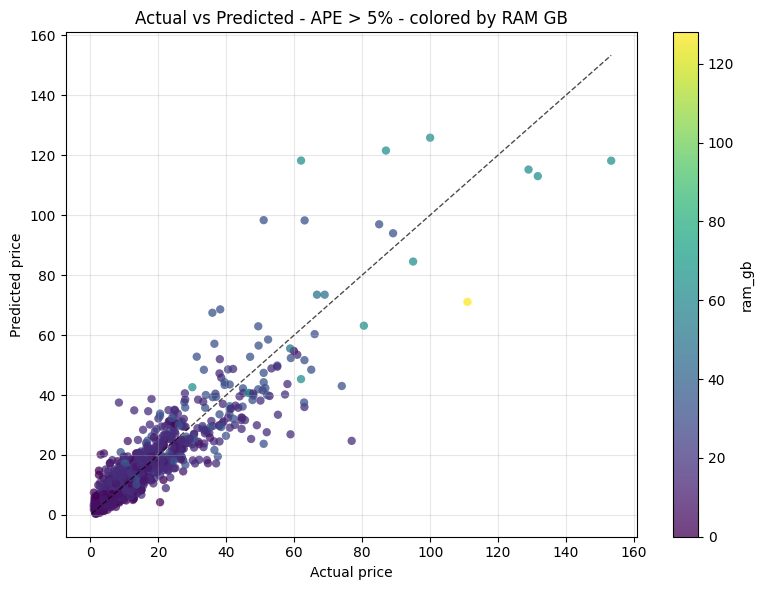

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\actual_vs_predicted_colored_by_ram_gb_outside_5pct_tolerance.png


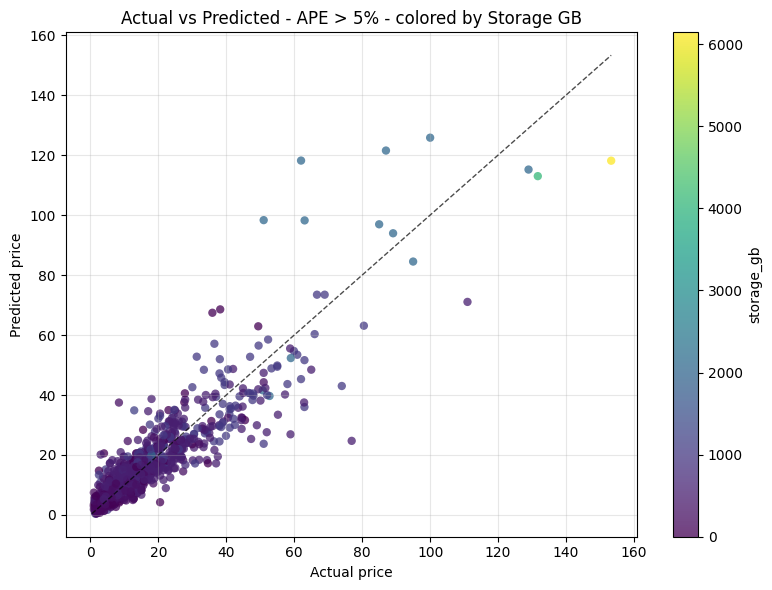

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\actual_vs_predicted_colored_by_storage_gb_outside_5pct_tolerance.png


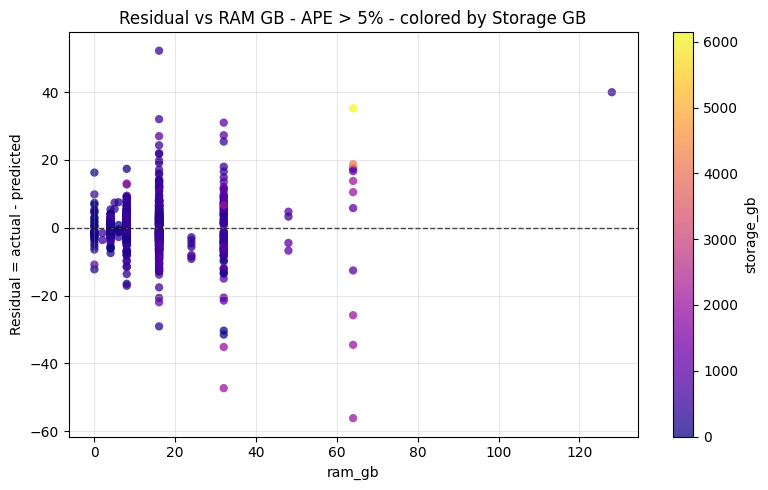

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\residual_vs_ram_gb_colored_by_storage_gb_outside_5pct_tolerance.png


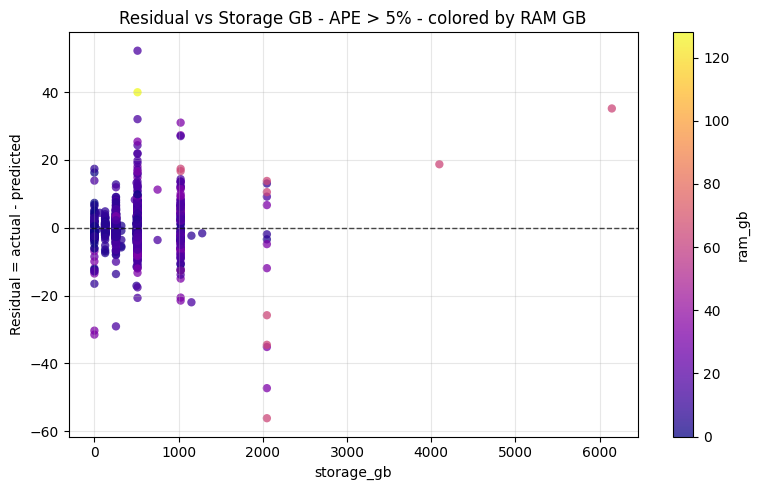

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\residual_vs_storage_gb_colored_by_ram_gb_outside_5pct_tolerance.png


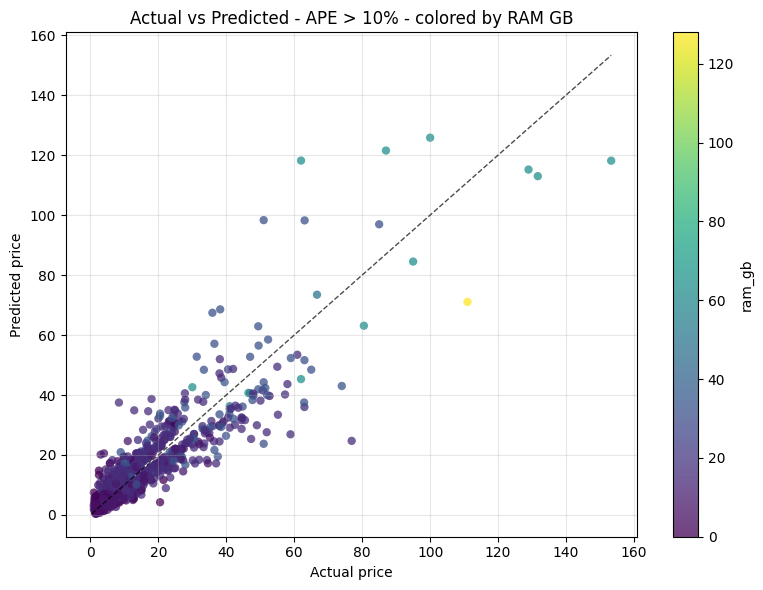

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\actual_vs_predicted_colored_by_ram_gb_outside_10pct_tolerance.png


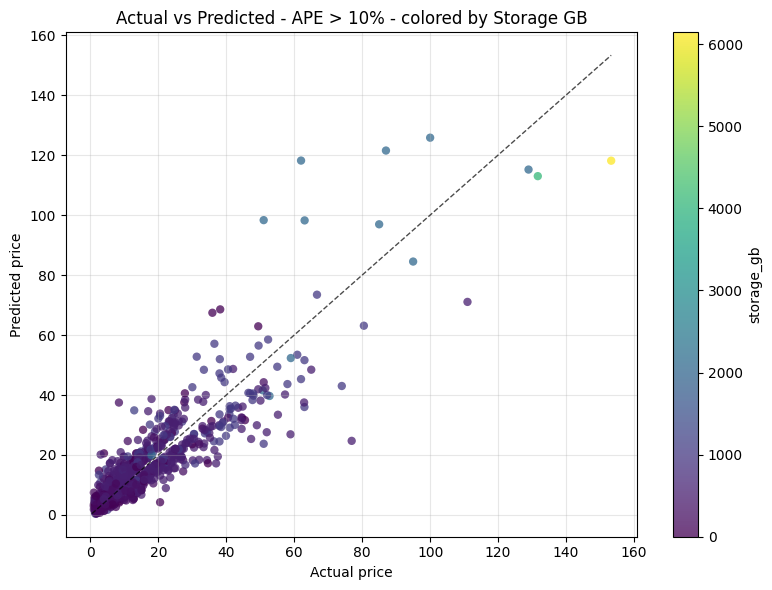

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\actual_vs_predicted_colored_by_storage_gb_outside_10pct_tolerance.png


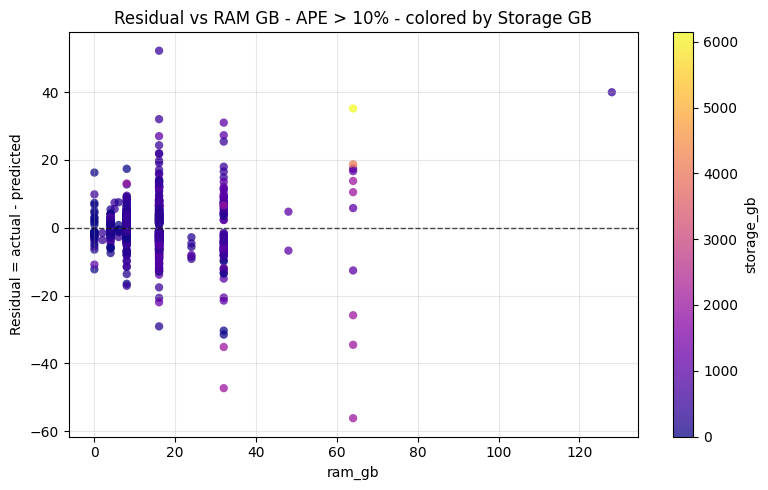

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\residual_vs_ram_gb_colored_by_storage_gb_outside_10pct_tolerance.png


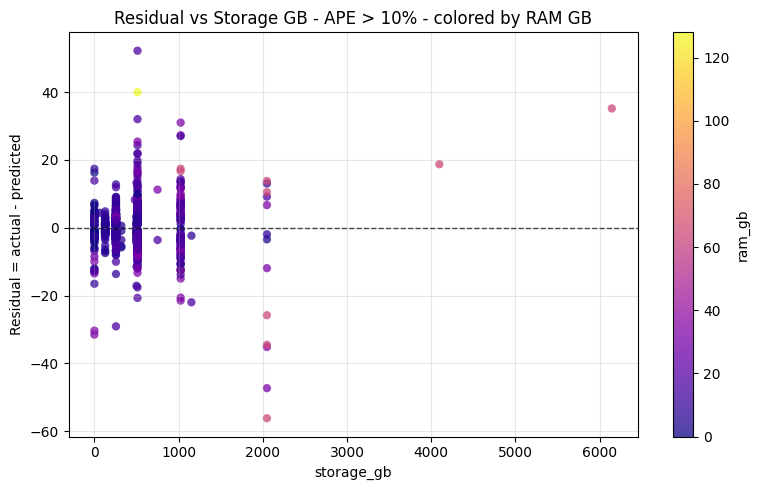

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\residual_vs_storage_gb_colored_by_ram_gb_outside_10pct_tolerance.png


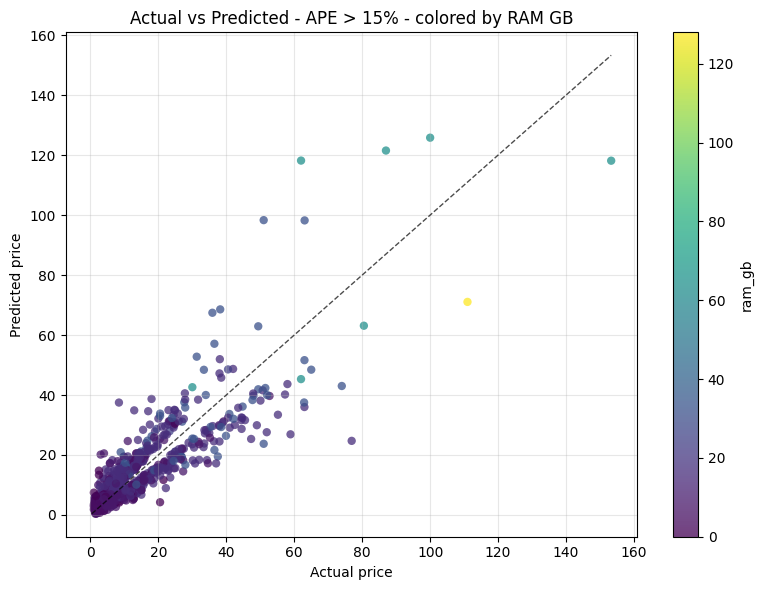

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\actual_vs_predicted_colored_by_ram_gb_outside_15pct_tolerance.png


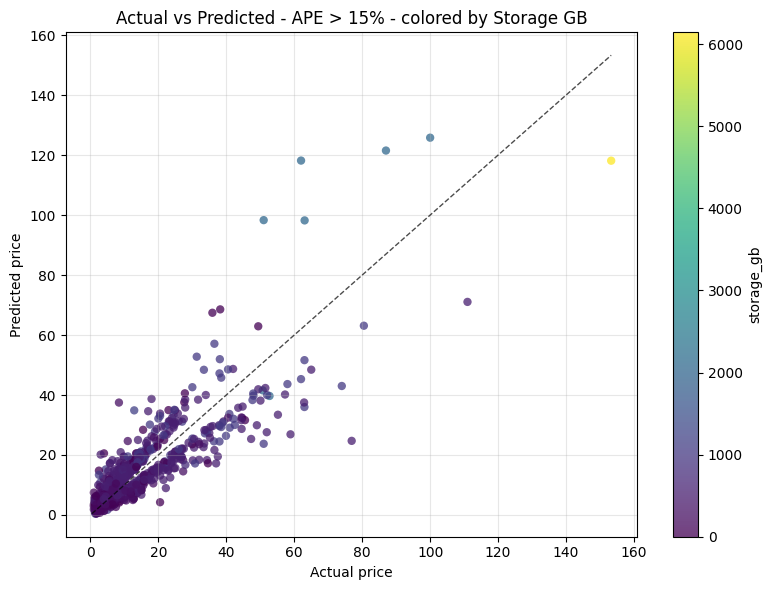

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\actual_vs_predicted_colored_by_storage_gb_outside_15pct_tolerance.png


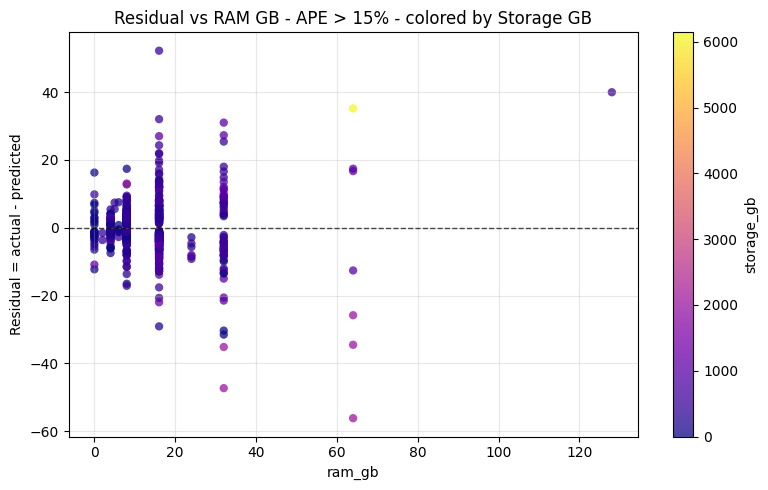

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\residual_vs_ram_gb_colored_by_storage_gb_outside_15pct_tolerance.png


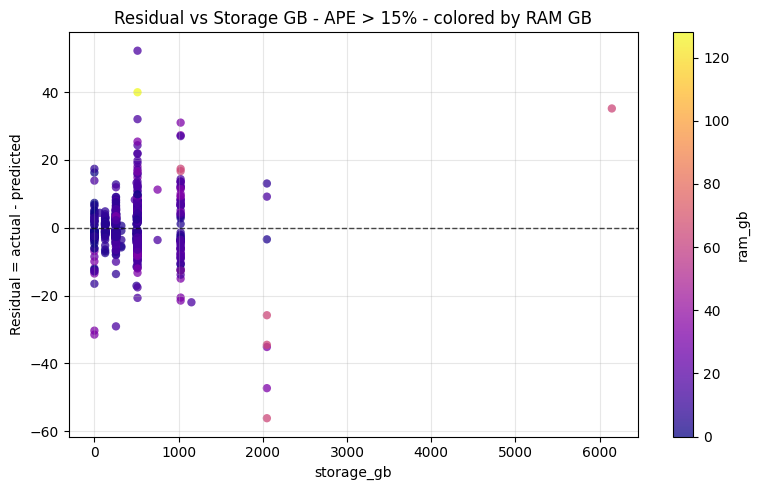

Saved plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\residual_vs_storage_gb_colored_by_ram_gb_outside_15pct_tolerance.png
Tolerance diagnostic plots created: 12


In [13]:
tolerance_plot_paths = []
tolerance_thresholds = [5, 10, 15]

tolerance_rows = []
for tolerance_pct in tolerance_thresholds:
    outside_df = error_context_df[error_context_df["ape_pct"] > tolerance_pct]
    tolerance_rows.append({
        "tolerance_pct": tolerance_pct,
        "n_outside_tolerance": int(len(outside_df)),
        "pct_outside_tolerance": len(outside_df) / len(error_context_df) * 100,
        "n_within_or_equal_tolerance_hidden": int(len(error_context_df) - len(outside_df)),
    })

tolerance_summary_df = pd.DataFrame(tolerance_rows)
display(tolerance_summary_df)

tolerance_summary_path = ERROR_ANALYSIS_REPORT_DIR / "prediction_error_tolerance_summary.csv"
tolerance_summary_df.to_csv(tolerance_summary_path, index=False)
print(f"Saved tolerance summary to: {tolerance_summary_path}")

for tolerance_pct in tolerance_thresholds:
    plot_suffix = f"outside_{tolerance_pct}pct_tolerance"

    plot_specs = [
        (
            save_actual_predicted_scatter_by_color,
            {
                "color_col": ram_col,
                "filename": f"actual_vs_predicted_colored_by_ram_gb_{plot_suffix}.png",
                "title": f"Actual vs Predicted - APE > {tolerance_pct}% - colored by RAM GB",
                "tolerance_pct": tolerance_pct,
            },
        ),
        (
            save_actual_predicted_scatter_by_color,
            {
                "color_col": storage_col,
                "filename": f"actual_vs_predicted_colored_by_storage_gb_{plot_suffix}.png",
                "title": f"Actual vs Predicted - APE > {tolerance_pct}% - colored by Storage GB",
                "tolerance_pct": tolerance_pct,
            },
        ),
        (
            save_residual_scatter_by_feature,
            {
                "x_col": ram_col,
                "color_col": storage_col,
                "filename": f"residual_vs_ram_gb_colored_by_storage_gb_{plot_suffix}.png",
                "title": f"Residual vs RAM GB - APE > {tolerance_pct}% - colored by Storage GB",
                "tolerance_pct": tolerance_pct,
            },
        ),
        (
            save_residual_scatter_by_feature,
            {
                "x_col": storage_col,
                "color_col": ram_col,
                "filename": f"residual_vs_storage_gb_colored_by_ram_gb_{plot_suffix}.png",
                "title": f"Residual vs Storage GB - APE > {tolerance_pct}% - colored by RAM GB",
                "tolerance_pct": tolerance_pct,
            },
        ),
    ]

    for plot_func, kwargs in plot_specs:
        path = plot_func(error_context_df, **kwargs)
        if path is not None:
            tolerance_plot_paths.append(path)

print("Tolerance diagnostic plots created:", len(tolerance_plot_paths))

## RAM / Storage Error Pattern Interpretation

Các biểu đồ trên kiểm tra các case có `APE` vượt các ngưỡng `5%`, `10%`, và `15%`, tập trung vào mối quan hệ giữa sai số dự đoán với `ram_gb` và `storage_gb`.

Residual được định nghĩa là:

```text
residual = actual_price - predicted_price
```

Vì vậy:

```text
residual > 0  → model underpredict, dự đoán thấp hơn giá thực tế
residual < 0  → model overpredict, dự đoán cao hơn giá thực tế
```

### Tolerance overview

Bảng tolerance cho thấy phần lớn holdout samples vẫn nằm ngoài các mức sai số phần trăm nhỏ:

```text
APE > 5%  : 1240 cases, chiếm khoảng 84.93%
APE > 10% : 1049 cases, chiếm khoảng 71.85%
APE > 15% : 859 cases, chiếm khoảng 58.84%
```

Điều này cho thấy bài toán dự đoán giá laptop vẫn có độ nhiễu cao nếu đánh giá bằng phần trăm sai số. Tuy nhiên, cần đọc kết quả này cẩn thận vì với các máy giá thấp, chỉ cần lệch vài đơn vị giá thì APE đã có thể tăng mạnh. Vì vậy, `APE` nên được dùng cùng với `MAE`, `RMSE`, và residual plot thay vì dùng riêng lẻ.

### Residual vs RAM

Ở biểu đồ `Residual vs RAM GB`, phần lớn điểm dữ liệu tập trung tại các mức RAM phổ biến như `8GB`, `16GB`, và `32GB`. Đây là các vùng có mật độ dữ liệu cao nhất nên model học ổn định hơn tương đối.

Tuy nhiên, các case RAM cao như `64GB` và `128GB` có residual phân tán rất mạnh. Một số điểm residual âm sâu, tức model overpredict mạnh, trong khi một số điểm residual dương lớn, tức model underpredict mạnh. Điều này cho thấy RAM cao không phải lúc nào cũng đồng nghĩa với giá cao theo một quan hệ tuyến tính đơn giản. Giá còn phụ thuộc vào CPU, GPU, brand, dòng máy, warranty, condition và phân khúc sản phẩm.

Đặc biệt, nhóm `64GB RAM` có cả underprediction và overprediction lớn. Đây là tín hiệu nên kiểm tra thủ công trong file full feature audit, vì có thể tồn tại các máy workstation/gaming/premium thật sự đắt, nhưng cũng có những máy RAM cao nhưng đời cũ hoặc brand/series không quá premium.

### Residual vs Storage

Ở biểu đồ `Residual vs Storage GB`, các mức storage phổ biến như `256GB`, `512GB`, và `1024GB` chiếm phần lớn dữ liệu. Sai số tại các vùng này phân bố quanh đường residual = 0, nhưng vẫn có nhiều case lệch đáng kể.

Các điểm storage rất cao như `2048GB`, `4096GB`, và `6144GB` có số lượng ít hơn và sai số biến động mạnh hơn. Một số case storage cao bị model overpredict mạnh, cho thấy model có thể đánh giá quá cao tác động của dung lượng lưu trữ nếu thiếu ngữ cảnh về brand, dòng máy, GPU/CPU hoặc condition.

Ngược lại, cũng có một số case storage cao nhưng residual dương, tức giá thực tế cao hơn dự đoán. Điều này thường xảy ra khi storage cao đi kèm với các yếu tố premium khác nhưng model chưa capture đủ tốt.

### Actual vs Predicted

Các biểu đồ `Actual vs Predicted` cho thấy phần lớn điểm dữ liệu vẫn nằm gần đường chéo, đặc biệt ở vùng giá thấp đến trung bình. Tuy nhiên, khi actual price tăng lên, độ phân tán tăng rõ rệt.

Ở nhóm giá cao, có nhiều điểm nằm xa đường chéo:

* Điểm nằm dưới đường chéo: model underpredict, giá thực tế cao hơn dự đoán.
* Điểm nằm trên đường chéo: model overpredict, giá dự đoán cao hơn giá thực tế.

Điều này xác nhận lại kết luận từ error analysis trước đó: model gặp khó nhất ở phân khúc laptop giá cao. Với các máy đắt tiền, chỉ RAM/storage cao là chưa đủ để giải thích giá. Cần thêm thông tin về model/series, GPU cụ thể, CPU generation, màn hình, build quality, dòng gaming/workstation/business/premium và các đặc trưng sản phẩm khác.

### Main takeaway

Các biểu đồ cho thấy `ram_gb` và `storage_gb` là những feature quan trọng, nhưng tác động của chúng lên giá không tuyến tính và không độc lập. Sai số lớn thường xuất hiện ở các cấu hình RAM/storage cao hoặc bất thường, đặc biệt trong phân khúc giá cao.

Vì vậy, hướng cải thiện tiếp theo không nên chỉ thêm biến RAM/storage đơn lẻ, mà nên tập trung vào:

* Tạo interaction feature giữa RAM, storage, CPU tier, GPU tier và brand segment.
* Kiểm tra riêng các case `64GB RAM`, `128GB RAM`, `2TB+ storage`.
* Soi thủ công các dòng overprediction lớn để xem model có đang đánh giá quá cao RAM/storage hay không.
* Soi thủ công các dòng underprediction lớn để xem có thiếu tín hiệu premium như model/series, GPU mạnh hoặc dòng máy cao cấp hay không.
* Bổ sung/làm sạch thông tin `model`, `series`, hoặc product line nếu dữ liệu gốc cho phép.

Tóm lại, RAM và storage giúp model phân biệt cấu hình, nhưng chưa đủ để giải thích toàn bộ biến động giá. Với laptop cao cấp, model cần thêm các feature mang tính phân khúc và product-line để giảm sai số.

> Các tolerance threshold này chỉ dùng để quan sát phân bố lỗi tương đối, không dùng làm tiêu chuẩn pass/fail cho production.

## High Error Case Feature Audit

Section này export toàn bộ feature của các case lỗi cao để audit thủ công.

`residual = actual_price - predicted_price`, vì vậy residual dương lớn là underprediction và residual âm lớn là overprediction.

Các file full audit chứa toàn bộ feature đang đưa vào model, không chỉ feature quan trọng hay feature SHAP. Điều này giúp kiểm tra các tín hiệu sparse, one-hot, CPU/GPU, brand, warranty, condition và các feature engineered khác.

In [14]:
TOP_N_ERROR_CASES = 100

if "price_segment" not in error_context_df.columns:
    error_context_df["price_segment"] = pd.qcut(
        error_context_df["actual_price"],
        q=5,
        labels=["Q1_low", "Q2", "Q3", "Q4", "Q5_high"],
        duplicates="drop",
    )

top_abs_error_cases = (
    error_context_df
    .sort_values("abs_error", ascending=False)
    .head(TOP_N_ERROR_CASES)
    .copy()
)

top_underprediction_cases = (
    error_context_df
    .sort_values("residual", ascending=False)
    .head(TOP_N_ERROR_CASES)
    .copy()
)

top_overprediction_cases = (
    error_context_df
    .sort_values("residual", ascending=True)
    .head(TOP_N_ERROR_CASES)
    .copy()
)

print("Top absolute error cases:", top_abs_error_cases.shape)
print("Top underprediction cases:", top_underprediction_cases.shape)
print("Top overprediction cases:", top_overprediction_cases.shape)

Top absolute error cases: (100, 12)
Top underprediction cases: (100, 12)
Top overprediction cases: (100, 12)


In [15]:
def build_full_feature_audit(error_df, X, feature_names):
    audit_df = error_df.copy()
    sample_indices = audit_df["sample_index"].astype(int).tolist()

    missing_indices = [idx for idx in sample_indices if idx not in X.index]
    if missing_indices:
        raise ValueError(
            "Some sample_index values are not present in X.index: "
            f"{missing_indices[:20]}"
        )

    feature_audit_base = X.loc[sample_indices, feature_names].copy()
    feature_audit_base.columns = [f"feature__{c}" for c in feature_audit_base.columns]
    feature_audit_base = feature_audit_base.reset_index(drop=True)

    audit_df = audit_df.reset_index(drop=True)
    return pd.concat([audit_df, feature_audit_base], axis=1)


def save_full_feature_audit(case_df, filename):
    audit_df = build_full_feature_audit(case_df, X, feature_names)
    path = ERROR_ANALYSIS_REPORT_DIR / filename
    audit_df.to_csv(path, index=False)
    print(f"Saved {audit_df.shape[0]} rows x {audit_df.shape[1]} columns to: {path}")
    return audit_df


audit_top_abs_df = save_full_feature_audit(
    top_abs_error_cases,
    "high_error_cases_all_features_top_abs.csv",
)

audit_underprediction_df = save_full_feature_audit(
    top_underprediction_cases,
    "high_error_cases_all_features_underprediction.csv",
)

audit_overprediction_df = save_full_feature_audit(
    top_overprediction_cases,
    "high_error_cases_all_features_overprediction.csv",
)

expected_feature_cols = [f"feature__{c}" for c in feature_names]
missing_feature_audit_cols = [c for c in expected_feature_cols if c not in audit_top_abs_df.columns]

if missing_feature_audit_cols:
    raise ValueError(f"Feature audit is missing model features: {missing_feature_audit_cols[:20]}")

print("Full feature audit includes all model features:", len(expected_feature_cols))
display(audit_top_abs_df.head())

Saved 100 rows x 98 columns to: Y:\Python\Laptop-Price-Prediction\reports\error_analysis\high_error_cases_all_features_top_abs.csv
Saved 100 rows x 98 columns to: Y:\Python\Laptop-Price-Prediction\reports\error_analysis\high_error_cases_all_features_underprediction.csv
Saved 100 rows x 98 columns to: Y:\Python\Laptop-Price-Prediction\reports\error_analysis\high_error_cases_all_features_overprediction.csv
Full feature audit includes all model features: 86


,sample_index,actual_price,predicted_price,residual,abs_error,ape_pct,model_label,ram_gb,storage_gb,condition_score,...,feature__ram_storage_product_scaled,feature__ram_storage_balance,feature__memory_storage_score,feature__is_entry_memory_storage,feature__is_mid_memory_storage,feature__is_premium_memory_storage,feature__brand_segment_premium,feature__brand_segment_business,feature__brand_segment_gaming_value,feature__brand_segment_rare
0,5913,62.000,118.171322,-56.171322,56.171322,90.598906,CatBoost_tuned,64.0,2048.0,3,...,16.0,4.0,15.973882,0,1,1,0,1,0,0
1,6739,76.900,24.710545,52.189455,52.189455,67.866651,CatBoost_tuned,16.0,512.0,3,...,1.0,1.0,11.906703,0,1,0,0,1,0,0
2,7187,50.999,98.310875,-47.311875,47.311875,92.770201,CatBoost_tuned,32.0,2048.0,3,...,8.0,2.0,14.618122,0,1,1,0,0,1,0
3,6262,110.990,71.045667,39.944333,39.944333,35.989128,CatBoost_tuned,128.0,512.0,3,...,8.0,1.0,15.959901,0,1,0,1,0,0,0
4,5661,63.050,98.220763,-35.170763,35.170763,55.782336,CatBoost_tuned,32.0,2048.0,3,...,8.0,2.0,14.618122,0,1,1,0,0,1,0


In [16]:
def format_non_zero_features(row, feature_names, max_features=80):
    non_zero_items = []

    for feature in feature_names:
        value = row.get(f"feature__{feature}")

        if pd.isna(value):
            continue

        if value != 0:
            if isinstance(value, (float, np.floating)):
                value_text = f"{value:.6g}"
            else:
                value_text = str(value)
            non_zero_items.append(f"{feature}={value_text}")

        if len(non_zero_items) >= max_features:
            non_zero_items.append(f"... truncated_after_{max_features}_features")
            break

    return "; ".join(non_zero_items)


compact_base_cols = [
    "sample_index",
    "actual_price",
    "predicted_price",
    "residual",
    "abs_error",
    "ape_pct",
    "price_segment",
]

raw_context_cols = [c for c in context_cols if c in audit_top_abs_df.columns]
compact_cols = [c for c in compact_base_cols + raw_context_cols if c in audit_top_abs_df.columns]

high_error_compact_df = audit_top_abs_df[compact_cols].copy()
high_error_compact_df["non_zero_features"] = audit_top_abs_df.apply(
    lambda row: format_non_zero_features(row, feature_names, max_features=80),
    axis=1,
)

compact_path = ERROR_ANALYSIS_REPORT_DIR / "high_error_cases_compact_top_abs.csv"
high_error_compact_df.to_csv(compact_path, index=False)

display(high_error_compact_df.head(20))
print(f"Saved compact high-error audit to: {compact_path}")

,sample_index,actual_price,predicted_price,residual,abs_error,ape_pct,price_segment,ram_gb,storage_gb,condition_score,screen_size_inch,non_zero_features
0,5913,62.000,118.171322,-56.171322,56.171322,90.598906,Q5_high,64.0,2048.0,3,16.00,ram_gb=64; storage_gb=2048; screen_size_inch=1...
1,6739,76.900,24.710545,52.189455,52.189455,67.866651,Q5_high,16.0,512.0,3,15.60,ram_gb=16; storage_gb=512; screen_size_inch=15...
2,7187,50.999,98.310875,-47.311875,47.311875,92.770201,Q5_high,32.0,2048.0,3,17.00,ram_gb=32; storage_gb=2048; screen_size_inch=1...
3,6262,110.990,71.045667,39.944333,39.944333,35.989128,Q5_high,128.0,512.0,3,14.00,ram_gb=128; storage_gb=512; screen_size_inch=1...
4,5661,63.050,98.220763,-35.170763,35.170763,55.782336,Q5_high,32.0,2048.0,3,17.30,ram_gb=32; storage_gb=2048; screen_size_inch=1...
5,5967,153.290,118.129405,35.160595,35.160595,22.937305,Q5_high,64.0,6144.0,3,18.00,ram_gb=64; storage_gb=6144; screen_size_inch=1...
6,7056,86.990,121.517049,-34.527049,34.527049,39.690825,Q5_high,64.0,2048.0,3,16.00,ram_gb=64; storage_gb=2048; screen_size_inch=1...
7,6501,58.899,26.890328,32.008672,32.008672,54.345017,Q5_high,16.0,512.0,3,14.00,ram_gb=16; storage_gb=512; screen_size_inch=14...
8,5786,35.900,67.423989,-31.523989,31.523989,87.810554,Q5_high,32.0,0.0,3,16.00,ram_gb=32; screen_size_inch=16; storage_missin...
9,7029,73.990,43.004582,30.985418,30.985418,41.877846,Q5_high,32.0,1024.0,3,16.00,ram_gb=32; storage_gb=1024; screen_size_inch=1...


Saved compact high-error audit to: Y:\Python\Laptop-Price-Prediction\reports\error_analysis\high_error_cases_compact_top_abs.csv


## High Error Case Feature Audit Interpretation

Trong 100 case lỗi cao nhất, sai số tuyệt đối trung bình khoảng `17.03`, median absolute error khoảng `13.40`, trong khi MAPE trung bình khoảng `76.80%`. Điều này cho thấy nhóm top error không chỉ gồm các dòng giá cao bị lệch mạnh, mà còn có một số dòng giá thấp/trung bình bị sai theo tỷ lệ phần trăm rất lớn.

Về hướng sai số, nhóm lỗi cao tương đối cân bằng giữa underprediction và overprediction:

```text
Underprediction cases: 54
Overprediction cases: 46
```

Điều này cho thấy model không bị lệch hoàn toàn theo một chiều trong nhóm lỗi lớn. Vấn đề chính nằm ở các case khó, outlier hoặc các cấu hình đặc biệt hơn là một bias đơn giản kiểu luôn dự đoán cao hoặc luôn dự đoán thấp.

### Error concentration by price segment

Phần lớn lỗi cao tập trung ở phân khúc `Q5_high`:

```text
Q5_high: 73 / 100 cases
```

Đây là tín hiệu quan trọng nhất. Nhóm laptop giá cao có sai số tuyệt đối lớn nhất vì giá trị thực tế cao hơn, cấu hình đa dạng hơn và thường chứa nhiều yếu tố khó học như dòng máy premium, GPU/CPU mạnh, RAM/storage lớn, hoặc các mẫu máy hiếm. Vì vậy, nếu tiếp tục cải thiện model, nên ưu tiên phân tích sâu nhóm `Q5_high` thay vì tối ưu đều cho toàn bộ dataset.

Tuy nhiên, các segment thấp hơn như `Q1_low`, `Q2`, `Q3` vẫn có MAPE rất cao trong một số case. Điều này thường xảy ra khi actual price nhỏ, chỉ cần lệch vài đơn vị giá cũng làm phần trăm lỗi tăng mạnh. Vì vậy khi đánh giá model, cần đọc MAE/RMSE song song với MAPE, không nên chỉ dựa vào MAPE.

### Feature patterns in high-error cases

Các feature xuất hiện nhiều trong nhóm lỗi cao gồm:

```text
no_info_model: 92 cases
cpu_brand_Intel: 78 cases
warranty_not_activated: 73 cases
is_mid_memory_storage: 73 cases
gpu_tier_ord_filled: 63 cases
cpu_family_group_Intel Core i: 54 cases
brand_segment_business: 52 cases
is_premium_memory_storage: 24 cases
```

Việc `no_info_model` xuất hiện ở phần lớn top error cases cho thấy thiếu thông tin model cụ thể có thể làm model khó phân biệt các dòng máy cùng brand/cấu hình nhưng khác phân khúc giá. Ví dụ cùng RAM, storage, CPU nhưng khác series hoặc build quality thì giá có thể chênh lệch lớn.

Các feature liên quan đến memory/storage như `ram_gb`, `storage_gb`, `ram_storage_product_scaled`, `ram_storage_balance`, `memory_storage_score`, `is_mid_memory_storage`, và `is_premium_memory_storage` cũng xuất hiện dày đặc. Điều này cho thấy các case lỗi cao thường liên quan đến cấu hình RAM/storage lớn hoặc bất thường. Với laptop cao cấp, RAM/storage không tăng giá tuyến tính đơn giản, nên model có thể overpredict hoặc underpredict nếu thiếu thêm thông tin về dòng máy, GPU, đời CPU hoặc phân khúc sản phẩm.

Feature `warranty_not_activated` xuất hiện nhiều trong nhóm lỗi cao. Đây có thể là tín hiệu của các máy mới/chưa active bảo hành, thường liên quan đến giá cao hơn. Tuy nhiên, warranty một mình không đủ giải thích giá nếu thiếu thông tin về model, brand segment hoặc cấu hình chi tiết.

### Underprediction and overprediction interpretation

Với residual được định nghĩa là:

```text
residual = actual_price - predicted_price
```

Residual dương nghĩa là model đang underpredict, tức dự đoán thấp hơn giá thực tế. Residual âm nghĩa là model đang overpredict, tức dự đoán cao hơn giá thực tế.

Trong nhóm lỗi cao, underprediction nhiều hơn một chút so với overprediction. Điều này cho thấy một số máy cao cấp có giá thực tế vượt ngoài mức model kỳ vọng dựa trên feature hiện có. Nguyên nhân có thể đến từ các yếu tố chưa được capture tốt như model name, dòng máy flagship, chất lượng màn hình, thiết kế mỏng nhẹ, vật liệu, hoặc độ hiếm của sản phẩm.

Ngược lại, các overprediction case thường xảy ra khi model thấy nhiều tín hiệu cấu hình mạnh như RAM/storage cao, CPU/GPU tier cao hoặc warranty tốt, nhưng giá thực tế lại thấp hơn kỳ vọng. Điều này có thể đến từ máy cũ hơn, brand/series kém premium hơn, tình trạng máy không phản ánh hết trong feature, hoặc dữ liệu thiếu một số thông tin quan trọng.

### Why full feature logging is useful

File compact chỉ hiển thị các feature khác 0 để dễ đọc nhanh. Tuy nhiên, các file full audit như:

```text
high_error_cases_all_features_top_abs.csv
high_error_cases_all_features_underprediction.csv
high_error_cases_all_features_overprediction.csv
```

mới là phần quan trọng nhất để kiểm tra thủ công. Các file này chứa toàn bộ feature được đưa vào model, bao gồm feature sparse, one-hot, CPU/GPU, brand, warranty, condition và các interaction feature. Nhờ đó có thể soi từng dòng lỗi cao để xem model đang nhận được tín hiệu gì, có feature nào thiếu bất thường, hoặc có pattern nào lặp lại trong các case sai lớn.


## High-error Feature Frequency Analysis

Section này kiểm tra các feature binary/one-hot xuất hiện nhiều hơn trong nhóm lỗi cao so với toàn bộ holdout của model final.

`lift > 1` nghĩa là feature xuất hiện trong nhóm lỗi cao thường xuyên hơn baseline holdout. Đây là tín hiệu audit, không phải bằng chứng nhân quả và không được dùng để chọn lại model trong notebook này.

In [17]:
TOP_FEATURE_FREQUENCY_MIN_COUNT = 3

holdout_indices = error_context_df["sample_index"].astype(int).tolist()
top_error_indices = top_abs_error_cases["sample_index"].astype(int).tolist()

X_holdout = X.loc[holdout_indices, feature_names].copy()
X_top_errors = X.loc[top_error_indices, feature_names].copy()

binary_feature_cols = []
for col in X_holdout.select_dtypes(include=[np.number]).columns:
    values = X_holdout[col].dropna().unique()
    if len(values) <= 2 and set(values).issubset({0, 1, 0.0, 1.0}):
        binary_feature_cols.append(col)

frequency_rows = []

for col in binary_feature_cols:
    count_top = int((X_top_errors[col] != 0).sum())
    count_holdout = int((X_holdout[col] != 0).sum())
    pct_top = count_top / len(X_top_errors) if len(X_top_errors) else np.nan
    pct_holdout = count_holdout / len(X_holdout) if len(X_holdout) else np.nan

    if pct_holdout == 0 or pd.isna(pct_holdout):
        lift = np.nan
    else:
        lift = pct_top / pct_holdout

    frequency_rows.append({
        "feature": col,
        "count_nonzero_in_top_errors": count_top,
        "pct_nonzero_in_top_errors": pct_top,
        "count_nonzero_in_all_holdout": count_holdout,
        "pct_nonzero_in_all_holdout": pct_holdout,
        "lift": lift,
    })

high_error_feature_frequency_df = (
    pd.DataFrame(frequency_rows)
    .sort_values(["lift", "count_nonzero_in_top_errors"], ascending=[False, False])
    .reset_index(drop=True)
)

frequency_path = ERROR_ANALYSIS_REPORT_DIR / "high_error_feature_frequency.csv"
high_error_feature_frequency_df.to_csv(frequency_path, index=False)

feature_frequency_display_df = high_error_feature_frequency_df[
    high_error_feature_frequency_df["count_nonzero_in_top_errors"] >= TOP_FEATURE_FREQUENCY_MIN_COUNT
].head(30)

display(feature_frequency_display_df)
print("Binary/one-hot features checked:", len(binary_feature_cols))
print(f"Saved high-error feature frequency table to: {frequency_path}")

,feature,count_nonzero_in_top_errors,pct_nonzero_in_top_errors,count_nonzero_in_all_holdout,pct_nonzero_in_all_holdout,lift
1,is_premium_memory_storage,24,0.24,66,0.045205,5.309091
2,cpu_family_group_Intel Core Ultra,16,0.16,50,0.034247,4.672000
3,warranty_not_activated,73,0.73,377,0.258219,2.827056
4,brand_MSI,11,0.11,67,0.045890,2.397015
5,no_info_cpu_tier,17,0.17,112,0.076712,2.216071
6,no_info_brand,9,0.09,63,0.043151,2.085714
7,is_mid_memory_storage,73,0.73,531,0.363699,2.007156
8,brand_is_rare,3,0.03,23,0.015753,1.904348
9,brand_segment_rare,3,0.03,23,0.015753,1.904348
10,storage_missing,12,0.12,96,0.065753,1.825000


Binary/one-hot features checked: 73
Saved high-error feature frequency table to: Y:\Python\Laptop-Price-Prediction\reports\error_analysis\high_error_feature_frequency.csv


## High-error Feature Frequency Interpretation

Bảng trên phân tích tần suất xuất hiện của các binary/one-hot feature trong nhóm `top error cases`, sau đó so sánh với tần suất của chính feature đó trên toàn bộ holdout set.

Chỉ số quan trọng nhất ở đây là `lift`:

```text
lift = pct_nonzero_in_top_errors / pct_nonzero_in_all_holdout
```

Nếu `lift > 1`, feature đó xuất hiện trong nhóm lỗi cao nhiều hơn so với mặt bằng chung của holdout. Ngược lại, nếu `lift < 1`, feature đó không phải là tín hiệu nổi bật trong nhóm lỗi cao.

### Main findings

Feature có lift cao nhất là `is_premium_memory_storage`:

```text
pct in top errors  = 24.00%
pct in all holdout = 4.52%
lift               = 5.31
```

Điều này cho thấy các laptop có cấu hình RAM/storage premium xuất hiện trong nhóm lỗi cao nhiều hơn khoảng 5.3 lần so với toàn bộ holdout. Đây là tín hiệu rất mạnh rằng model vẫn gặp khó với các cấu hình bộ nhớ/lưu trữ cao cấp. Các case này thường không thể được giải thích chỉ bằng RAM và storage, vì giá còn phụ thuộc vào CPU, GPU, brand, dòng máy, warranty, condition và phân khúc sản phẩm.

Feature `cpu_family_group_Intel Core Ultra` cũng có lift rất cao:

```text
pct in top errors  = 16.00%
pct in all holdout = 3.42%
lift               = 4.67
```

Điều này cho thấy nhóm CPU Intel Core Ultra xuất hiện nhiều bất thường trong các case lỗi lớn. Có thể đây là nhóm CPU mới hơn, ít sample hơn, hoặc có giá biến động mạnh giữa các dòng máy. Vì vậy model có thể chưa học đủ ổn định cho nhóm này.

Feature `warranty_not_activated` xuất hiện trong 73% top error cases, trong khi chỉ chiếm khoảng 25.82% toàn bộ holdout:

```text
lift = 2.83
```

Đây là một tín hiệu quan trọng. Các máy chưa active bảo hành thường có thể là máy mới, máy cận new, hoặc máy có giá cao hơn mặt bằng chung. Tuy nhiên, warranty status một mình không đủ để giải thích giá nếu model thiếu thông tin model/series hoặc product line.

Feature `brand_MSI` có lift khoảng `2.40`, cho thấy MSI xuất hiện nhiều hơn trong nhóm lỗi cao. Điều này có thể liên quan đến laptop gaming, cấu hình mạnh, GPU rời, hoặc các dòng máy có giá dao động lớn theo series. Vì vậy, các case MSI nên được kiểm tra riêng trong file full feature audit.

Các feature thiếu thông tin như `no_info_cpu_tier`, `no_info_brand`, `storage_missing`, `no_info_cpu_brand`, `ram_missing`, `no_info_model`, và `no_info_storage` cũng xuất hiện với lift lớn hơn 1. Điều này cho thấy thiếu thông tin đầu vào vẫn là một nguyên nhân tiềm năng làm tăng sai số. Trong đó, `no_info_model` đặc biệt đáng chú ý vì nó xuất hiện ở 92% top error cases. Tuy lift chỉ khoảng `1.41`, tỷ lệ xuất hiện tuyệt đối rất cao, cho thấy model đang thiếu khả năng phân biệt chính xác các dòng máy cụ thể.

### Important non-signals

Không phải feature nào xuất hiện nhiều trong top error cases cũng là tín hiệu lỗi mạnh. Ví dụ:

```text
cpu_brand_Intel
storage_ssd
brand_segment_business
brand_Dell
brand_HP
brand_segment_premium
cpu_brand_Apple
```

Các feature này có lift gần hoặc dưới 1. Điều này nghĩa là chúng xuất hiện trong top error cases chủ yếu vì chúng cũng phổ biến trong toàn bộ holdout, không nhất thiết vì chúng làm model sai nhiều hơn.

Ví dụ `cpu_brand_Intel` xuất hiện trong 78% top error cases, nhưng cũng xuất hiện khoảng 78.22% trên toàn bộ holdout, nên lift gần bằng 1. Do đó không nên kết luận rằng CPU Intel nói chung là nguyên nhân gây lỗi. Tín hiệu đáng chú ý hơn nằm ở các nhóm cụ thể như `Intel Core Ultra`, không phải toàn bộ brand Intel.

Tương tự, `storage_ssd` xuất hiện nhiều trong top error cases nhưng lift dưới 1. Vì SSD là feature rất phổ biến trong toàn bộ dataset, nó không phải là pattern lỗi đặc biệt.

### Interpretation

Kết quả này cho thấy lỗi cao không đến từ một feature đơn lẻ, mà tập trung vào các nhóm có đặc điểm sau:

* Cấu hình RAM/storage premium.
* CPU family mới hoặc ít sample hơn, đặc biệt là Intel Core Ultra.
* Warranty chưa active.
* Một số brand hoặc segment có giá dao động mạnh như MSI.
* Các case bị thiếu thông tin quan trọng như model, CPU tier, brand, RAM hoặc storage.

Điều này khớp với các biểu đồ residual trước đó: model gặp khó nhất ở các cấu hình cao, hiếm hoặc thiếu ngữ cảnh sản phẩm. Những feature như RAM, storage, CPU và warranty có tín hiệu mạnh, nhưng nếu không có model/series hoặc product line thì model vẫn khó phân biệt giá thực tế.

### Next steps

Từ bảng này, các hướng cải thiện hợp lý là:

* Kiểm tra riêng các case có `is_premium_memory_storage = 1`.
* Kiểm tra riêng nhóm `cpu_family_group_Intel Core Ultra`.
* Phân tích các case `warranty_not_activated = 1` để xem model đang overpredict hay underpredict.
* Soi các dòng `brand_MSI` trong file full feature audit.
* Giảm tỷ lệ `no_info_model`, `no_info_cpu_tier`, `no_info_brand` nếu dữ liệu gốc cho phép.
* Bổ sung feature về model/series/product line để phân biệt tốt hơn các laptop cùng cấu hình nhưng khác phân khúc giá.

Tóm lại, bảng high-error feature frequency cho thấy model không sai ngẫu nhiên. Các lỗi lớn có xu hướng tập trung ở nhóm laptop cấu hình cao, thông tin thiếu, hoặc các nhóm sản phẩm có độ biến động giá lớn. Đây là nhóm nên ưu tiên nếu tiếp tục cải thiện model sau notebook 15.


## Underprediction Analysis

Underprediction means the actual price is higher than the predicted price.

This is risky when the model undervalues premium or high-spec laptops.

In [18]:
underprediction_df = (
    error_context_df[error_context_df["residual"] > 0]
    .sort_values("residual", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

display(underprediction_df)

underprediction_df.to_csv(
    ERROR_PRED_DIR / "top_underprediction_cases.csv",
    index=False,
)

,sample_index,actual_price,predicted_price,residual,abs_error,ape_pct,model_label,ram_gb,storage_gb,condition_score,screen_size_inch,price_segment
0,6739,76.900,24.710545,52.189455,52.189455,67.866651,CatBoost_tuned,16.0,512.0,3,15.60,Q5_high
1,6262,110.990,71.045667,39.944333,39.944333,35.989128,CatBoost_tuned,128.0,512.0,3,14.00,Q5_high
2,5967,153.290,118.129405,35.160595,35.160595,22.937305,CatBoost_tuned,64.0,6144.0,3,18.00,Q5_high
3,6501,58.899,26.890328,32.008672,32.008672,54.345017,CatBoost_tuned,16.0,512.0,3,14.00,Q5_high
4,7029,73.990,43.004582,30.985418,30.985418,41.877846,CatBoost_tuned,32.0,1024.0,3,16.00,Q5_high
5,3296,51.000,23.728654,27.271346,27.271346,53.473227,CatBoost_tuned,32.0,1024.0,2,13.95,Q5_high
6,6278,62.990,35.992770,26.997230,26.997230,42.859548,CatBoost_tuned,16.0,1024.0,3,14.00,Q5_high
7,5499,62.900,37.509785,25.390215,25.390215,40.366001,CatBoost_tuned,32.0,512.0,3,17.30,Q5_high
8,5907,51.900,27.590031,24.309969,24.309969,46.840017,CatBoost_tuned,16.0,512.0,3,13.30,Q5_high
9,5993,47.300,25.346381,21.953619,21.953619,46.413570,CatBoost_tuned,16.0,512.0,3,16.00,Q5_high


## Overprediction Analysis

Overprediction means the predicted price is higher than the actual price.

This is risky when the model overvalues weak-condition, expired-warranty, or older hardware laptops.

In [19]:
overprediction_df = (
    error_context_df[error_context_df["residual"] < 0]
    .assign(overprediction_amount=lambda d: -d["residual"])
    .sort_values("overprediction_amount", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

display(overprediction_df)

overprediction_df.to_csv(
    ERROR_PRED_DIR / "top_overprediction_cases.csv",
    index=False,
)

,sample_index,actual_price,predicted_price,residual,abs_error,ape_pct,model_label,ram_gb,storage_gb,condition_score,screen_size_inch,price_segment,overprediction_amount
0,5913,62.000,118.171322,-56.171322,56.171322,90.598906,CatBoost_tuned,64.0,2048.0,3,16.00,Q5_high,56.171322
1,7187,50.999,98.310875,-47.311875,47.311875,92.770201,CatBoost_tuned,32.0,2048.0,3,17.00,Q5_high,47.311875
2,5661,63.050,98.220763,-35.170763,35.170763,55.782336,CatBoost_tuned,32.0,2048.0,3,17.30,Q5_high,35.170763
3,7056,86.990,121.517049,-34.527049,34.527049,39.690825,CatBoost_tuned,64.0,2048.0,3,16.00,Q5_high,34.527049
4,5786,35.900,67.423989,-31.523989,31.523989,87.810554,CatBoost_tuned,32.0,0.0,3,16.00,Q5_high,31.523989
5,7118,38.200,68.549962,-30.349962,30.349962,79.450162,CatBoost_tuned,32.0,0.0,3,0.00,Q5_high,30.349962
6,6072,8.390,37.480304,-29.090304,29.090304,346.725912,CatBoost_tuned,16.0,256.0,3,15.60,Q3,29.090304
7,7133,99.999,125.805117,-25.806117,25.806117,25.806375,CatBoost_tuned,64.0,2048.0,3,18.00,Q5_high,25.806117
8,7045,12.890,34.879170,-21.989170,21.989170,170.590923,CatBoost_tuned,16.0,1152.0,3,15.60,Q3,21.989170
9,6410,31.290,52.777310,-21.487310,21.487310,68.671491,CatBoost_tuned,32.0,1024.0,3,16.10,Q5_high,21.487310


## Error by Price Segment

In [20]:
error_context_df["price_segment"] = pd.qcut(
    error_context_df["actual_price"],
    q=5,
    labels=["Q1_low", "Q2", "Q3", "Q4", "Q5_high"],
    duplicates="drop",
)

price_segment_error_df = (
    error_context_df
    .groupby("price_segment", observed=False)
    .agg(
        n_samples=("actual_price", "size"),
        mean_actual_price=("actual_price", "mean"),
        mae=("abs_error", "mean"),
        median_ae=("abs_error", "median"),
        rmse=("residual", lambda x: np.sqrt(np.mean(np.square(x)))),
        mape_pct=("ape_pct", "mean"),
        max_abs_error=("abs_error", "max"),
        mean_residual=("residual", "mean"),
    )
    .reset_index()
)

display(price_segment_error_df)

price_segment_error_df.to_csv(
    ERROR_METRIC_DIR / "error_by_price_segment.csv",
    index=False,
)

,price_segment,n_samples,mean_actual_price,mae,median_ae,rmse,mape_pct,max_abs_error,mean_residual
0,Q1_low,292,3.084314,1.826344,1.290852,2.805340,69.815879,17.128253,-1.508666
1,Q2,292,6.366653,1.722290,1.082984,2.574576,27.489450,11.838651,-0.882329
2,Q3,293,10.446911,2.706059,2.203139,3.927277,26.274350,29.090304,-0.478057
3,Q4,291,16.705713,3.042671,2.211349,4.234081,18.334031,20.696782,-0.100531
4,Q5_high,292,38.018270,7.566920,5.298590,11.267712,19.329177,56.171322,2.648896


## Error by Price Segment Interpretation

Bảng trên cho thấy sai số của model thay đổi khá rõ theo từng phân khúc giá. Mỗi segment có số lượng mẫu gần tương đương nhau, khoảng `291–293` dòng, nên việc so sánh giữa các nhóm là tương đối công bằng.

### Absolute error increases in high-price segment

Phân khúc có sai số tuyệt đối lớn nhất là `Q5_high`:

```text id="8im20j"
Q5_high
MAE           = 7.5669
RMSE          = 11.2677
Median AE     = 5.2986
Max abs error = 56.1713
```

Điều này cho thấy model gặp khó nhất ở nhóm laptop giá cao. So với các segment còn lại, `Q5_high` có MAE và RMSE cao hơn rất rõ. Đây là nhóm thường chứa các máy cấu hình mạnh, dòng premium, GPU/CPU cao cấp, RAM/storage lớn hoặc các product line đặc biệt. Vì vậy, chỉ các feature cấu hình cơ bản có thể chưa đủ để model phân biệt chính xác giá.

### Low-price segment has high MAPE

Mặc dù `Q1_low` có MAE thấp hơn nhiều so với `Q5_high`, MAPE của nhóm này lại cao nhất:

```text id="bx1757"
Q1_low
MAE      = 1.8263
MAPE     = 69.8159%
Mean actual price = 3.0843
```

Nguyên nhân là giá thực tế của nhóm này rất thấp. Khi mẫu số nhỏ, chỉ cần model lệch khoảng 1–2 đơn vị giá thì phần trăm sai số đã tăng rất mạnh. Vì vậy, MAPE ở nhóm giá thấp dễ bị phóng đại và không nên được dùng riêng lẻ để đánh giá chất lượng model.

Nói cách khác, `Q1_low` không phải là nhóm có lỗi tuyệt đối nặng nhất, nhưng là nhóm có lỗi phần trăm cao nhất do giá nền thấp.

### Middle segments are more stable

Các nhóm `Q2`, `Q3`, và `Q4` có sai số tương đối ổn định hơn:

```text id="6w637e"
Q2: MAE = 1.7223, RMSE = 2.5746
Q3: MAE = 2.7061, RMSE = 3.9273
Q4: MAE = 3.0427, RMSE = 4.2341
```

Sai số tuyệt đối tăng dần khi giá trung bình tăng, nhưng chưa có bước nhảy quá mạnh như ở `Q5_high`. Điều này cho thấy model đang học khá tốt các vùng giá phổ thông đến cận cao cấp, trong khi vùng giá cao nhất vẫn là vùng khó nhất.

### Residual bias by segment

Mean residual được tính bằng:

```text id="z5665o"
residual = actual_price - predicted_price
```

Vì vậy:

```text id="a8au3n"
mean_residual < 0 → model overpredict trung bình
mean_residual > 0 → model underpredict trung bình
```

Các segment từ `Q1_low` đến `Q4` đều có mean residual âm:

```text id="qhtczs"
Q1_low = -1.5087
Q2     = -0.8823
Q3     = -0.4781
Q4     = -0.1005
```

Điều này cho thấy model có xu hướng dự đoán cao hơn giá thực tế ở các nhóm giá thấp đến trung-cao. Mức overprediction giảm dần khi segment tăng.

Ngược lại, `Q5_high` có mean residual dương:

```text id="vrq2ll"
Q5_high = 2.6489
```

Điều này nghĩa là ở nhóm laptop giá cao, model có xu hướng underpredict, tức dự đoán thấp hơn giá thực tế. Đây là pattern quan trọng: model đang hơi kéo dự đoán về vùng trung bình, dẫn đến overpredict ở nhóm giá thấp và underpredict ở nhóm giá cao.

### Main takeaway

Kết quả theo price segment cho thấy model có hiện tượng regression-to-the-mean nhẹ:

* Với laptop giá thấp, model thường dự đoán cao hơn thực tế.
* Với laptop giá cao, model thường dự đoán thấp hơn thực tế.
* Nhóm `Q5_high` là nhóm có lỗi tuyệt đối lớn nhất.
* Nhóm `Q1_low` là nhóm có MAPE cao nhất do giá thực tế nhỏ.

Vì vậy, nếu tiếp tục cải thiện model, ưu tiên chính nên là giảm lỗi ở `Q5_high`, đặc biệt là các case bị underpredict mạnh. Hướng cải thiện có thể gồm bổ sung feature về model/series, product line, GPU cụ thể, CPU generation, brand segment, màn hình hoặc các tín hiệu premium mà feature hiện tại chưa capture đủ.


## Error by Product Attributes

Section này tổng hợp lỗi theo các attribute sản phẩm còn tồn tại trong final dataset/prediction context.

Một số raw attribute như `brand`, `cpu_brand`, `gpu_brand`, hoặc `warranty_encoded` có thể không còn tồn tại trong dataset final vì đã được encode hoặc không được giữ lại ở stage trước. Notebook chỉ group theo các cột có sẵn và log rõ các cột bị thiếu để audit.

In [21]:
group_cols = [
    "brand",
    "cpu_brand",
    "gpu_brand",
    "condition_score",
    "warranty_encoded",
]

available_group_cols = [c for c in group_cols if c in error_context_df.columns]
missing_group_cols = [c for c in group_cols if c not in error_context_df.columns]

print("Available group columns:", available_group_cols)
print("Missing group columns:", missing_group_cols)

if missing_group_cols:
    print(
        "Some raw product attributes are unavailable in the final dataset. "
        "They may have been encoded, transformed, or dropped in earlier preprocessing stages."
    )

Available group columns: ['condition_score']
Missing group columns: ['brand', 'cpu_brand', 'gpu_brand', 'warranty_encoded']
Some raw product attributes are unavailable in the final dataset. They may have been encoded, transformed, or dropped in earlier preprocessing stages.


In [22]:
def summarize_error_by_group(df_error, group_col, min_count=20):
    if group_col not in df_error.columns:
        return pd.DataFrame()

    summary = (
        df_error
        .groupby(group_col, dropna=False)
        .agg(
            count=("actual_price", "size"),
            mae=("abs_error", "mean"),
            rmse=("residual", lambda x: np.sqrt(np.mean(np.square(x)))),
            mape_pct=("ape_pct", "mean"),
            mean_residual=("residual", "mean"),
            underprediction_count=("residual", lambda x: int((x > 0).sum())),
            overprediction_count=("residual", lambda x: int((x < 0).sum())),
        )
        .reset_index()
    )

    return (
        summary[summary["count"] >= min_count]
        .sort_values("mae", ascending=False)
        .reset_index(drop=True)
    )


MIN_GROUP_COUNT = 20
group_error_frames = {}

for col in available_group_cols:
    group_df = summarize_error_by_group(
        error_context_df,
        col,
        min_count=MIN_GROUP_COUNT,
    )

    if group_df.empty:
        print(f"No groups for {col} meet min_count={MIN_GROUP_COUNT}.")
        continue

    group_error_frames[col] = group_df
    display(group_df.head(20))

    artifact_path = ERROR_ANALYSIS_REPORT_DIR / f"error_by_{col}.csv"
    group_df.to_csv(artifact_path, index=False)
    print(f"Saved grouped error table to: {artifact_path}")

if not group_error_frames:
    print("No product attribute group table was generated because no available group column met the sample threshold.")

,condition_score,count,mae,rmse,mape_pct,mean_residual,underprediction_count,overprediction_count
0,3,414,5.884877,9.584252,24.478427,-0.043455,194,220
1,2,1036,2.376105,3.523535,34.948800,-0.056917,469,567


Saved grouped error table to: Y:\Python\Laptop-Price-Prediction\reports\error_analysis\error_by_condition_score.csv


## Error by Condition Score Interpretation

Bảng trên so sánh sai số của model theo `condition_score`. Trong dữ liệu holdout hiện tại chỉ có hai nhóm condition xuất hiện là `2` và `3`.

### Condition score 3 has higher absolute error

Nhóm `condition_score = 3` có sai số tuyệt đối cao hơn rõ rệt:

```text id="3ksmig"
condition_score = 3
count = 414
MAE   = 5.8849
RMSE  = 9.5843
MAPE  = 24.4784%
```

Trong khi đó, nhóm `condition_score = 2` có MAE và RMSE thấp hơn:

```text id="34it7d"
condition_score = 2
count = 1036
MAE   = 2.3761
RMSE  = 3.5235
MAPE  = 34.9488%
```

Điều này cho thấy các máy có condition tốt hơn đang tạo ra sai số tuyệt đối lớn hơn. Tuy nhiên, không nên kết luận rằng `condition_score = 3` trực tiếp làm model sai. Khả năng cao nhóm này chứa nhiều laptop giá cao hơn, máy mới hơn, warranty tốt hơn hoặc cấu hình mạnh hơn, nên sai số tuyệt đối cũng tăng theo giá trị sản phẩm.

### MAPE is higher for condition score 2

Mặc dù `condition_score = 2` có MAE/RMSE thấp hơn, MAPE của nhóm này lại cao hơn:

```text id="h0117o"
condition_score = 2
MAPE = 34.9488%
```

Điều này có thể xảy ra nếu nhóm condition 2 có nhiều máy giá thấp hoặc trung bình. Với các máy giá thấp, chỉ cần lệch vài đơn vị giá thì phần trăm sai số đã tăng mạnh. Vì vậy, MAPE cao ở nhóm này không nhất thiết nghĩa là lỗi tuyệt đối nghiêm trọng hơn.

Nói cách khác:

```text id="o5e2o1"
condition_score = 3 → lỗi tuyệt đối lớn hơn
condition_score = 2 → lỗi phần trăm cao hơn
```

### Residual bias is small in both groups

Mean residual của cả hai nhóm đều gần 0:

```text id="o1iqfg"
condition_score = 3: mean_residual = -0.0435
condition_score = 2: mean_residual = -0.0569
```

Residual được định nghĩa là:

```text id="z02v07"
residual = actual_price - predicted_price
```

Vì vậy residual âm nghĩa là model hơi overpredict. Tuy nhiên, giá trị mean residual của cả hai nhóm đều rất nhỏ, nên không có dấu hiệu bias mạnh theo condition score.

Số lượng underprediction và overprediction cũng khá cân bằng:

```text id="fxqswg"
condition_score = 3: underprediction = 194, overprediction = 220
condition_score = 2: underprediction = 469, overprediction = 567
```

Cả hai nhóm đều có overprediction nhiều hơn một chút, nhưng chênh lệch không quá lớn.

### Main takeaway

Kết quả theo `condition_score` cho thấy condition có liên quan đến mức sai số, nhưng không phải là nguyên nhân độc lập duy nhất. Nhóm `condition_score = 3` có lỗi tuyệt đối cao hơn nhiều khả năng vì nhóm này chứa nhiều máy giá cao, máy mới hoặc cấu hình tốt hơn. Trong khi đó, nhóm `condition_score = 2` có MAPE cao hơn do giá nền thấp hơn.

Vì vậy, khi phân tích lỗi theo condition, nên kết hợp thêm với `price_segment`, `warranty`, `brand`, `CPU/GPU`, RAM và storage. Nếu tiếp tục cải thiện model, có thể kiểm tra thêm interaction giữa condition và các feature khác, ví dụ:

* `condition_score × price_segment`
* `condition_score × warranty_not_activated`
* `condition_score × brand_segment`
* `condition_score × RAM/storage`
* `condition_score × CPU/GPU tier`

Tóm lại, model không bị bias mạnh theo condition score, nhưng nhóm condition tốt hơn vẫn có sai số tuyệt đối cao hơn do thường gắn với các laptop có giá trị cao hơn và biến động giá lớn hơn.


## Rule-based Error Explanation

This section creates interpretable error tags for each prediction.

These tags do not prove the exact causal reason for an error. They summarize likely error patterns such as high-price samples, expired warranty, low condition, brand effects, or extreme relative error.

In [23]:
def explain_error(row):
    reasons = []

    residual = row["residual"]
    abs_error = row["abs_error"]
    ape = row["ape_pct"]

    if residual > 0:
        reasons.append("underpredicted_actual_higher_than_predicted")
    elif residual < 0:
        reasons.append("overpredicted_predicted_higher_than_actual")

    if "price_segment" in row and row["price_segment"] == "Q5_high":
        reasons.append("high_price_segment_rmse_sensitive")

    if ape >= 50:
        reasons.append("very_high_relative_error")

    if abs_error >= error_context_df["abs_error"].quantile(0.95):
        reasons.append("top_5_percent_absolute_error")

    if "condition_score" in row and pd.notna(row["condition_score"]):
        if row["condition_score"] <= 1:
            reasons.append("low_condition_may_reduce_real_price")
        elif row["condition_score"] >= 3:
            reasons.append("high_condition_may_increase_real_price")

    if "warranty_encoded" in row and pd.notna(row["warranty_encoded"]):
        if row["warranty_encoded"] == 0:
            reasons.append("expired_warranty_may_reduce_real_price")
        elif row["warranty_encoded"] == 2:
            reasons.append("not_activated_warranty_may_increase_real_price")

    if "brand" in row and pd.notna(row["brand"]):
        reasons.append(f"brand_effect_{row['brand']}")

    return "; ".join(reasons)


error_context_df["error_explanation_tags"] = error_context_df.apply(
    explain_error,
    axis=1,
)

display(
    error_context_df[[
        "sample_index",
        "actual_price",
        "predicted_price",
        "residual",
        "abs_error",
        "ape_pct",
        "error_explanation_tags",
    ]]
    .sort_values("abs_error", ascending=False)
    .head(30)
)

error_context_df.to_csv(
    ERROR_PRED_DIR / "final_model_errors_with_explanation_tags.csv",
    index=False,
)

,sample_index,actual_price,predicted_price,residual,abs_error,ape_pct,error_explanation_tags
5800,5913,62.000,118.171322,-56.171322,56.171322,90.598906,overpredicted_predicted_higher_than_actual; hi...
4945,6739,76.900,24.710545,52.189455,52.189455,67.866651,underpredicted_actual_higher_than_predicted; h...
5300,7187,50.999,98.310875,-47.311875,47.311875,92.770201,overpredicted_predicted_higher_than_actual; hi...
5064,6262,110.990,71.045667,39.944333,39.944333,35.989128,underpredicted_actual_higher_than_predicted; h...
5322,5661,63.050,98.220763,-35.170763,35.170763,55.782336,overpredicted_predicted_higher_than_actual; hi...
4626,5967,153.290,118.129405,35.160595,35.160595,22.937305,underpredicted_actual_higher_than_predicted; h...
5355,7056,86.990,121.517049,-34.527049,34.527049,39.690825,overpredicted_predicted_higher_than_actual; hi...
5500,6501,58.899,26.890328,32.008672,32.008672,54.345017,underpredicted_actual_higher_than_predicted; h...
4967,5786,35.900,67.423989,-31.523989,31.523989,87.810554,overpredicted_predicted_higher_than_actual; hi...
5230,7029,73.990,43.004582,30.985418,30.985418,41.877846,underpredicted_actual_higher_than_predicted; h...


## Top Error Cases Interpretation

Bảng trên hiển thị các dòng có sai số tuyệt đối lớn nhất trên holdout set. Đây là nhóm cần được kiểm tra thủ công vì chúng đại diện cho các case mà model dự đoán lệch mạnh nhất.

Residual được định nghĩa là:

```text id="4bk8sl"
residual = actual_price - predicted_price
```

Vì vậy:

```text id="zsqe0i"
residual > 0 → model underpredict, dự đoán thấp hơn giá thực tế
residual < 0 → model overpredict, dự đoán cao hơn giá thực tế
```

### Largest error cases

Case có lỗi lớn nhất là sample `5913`:

```text id="d81z7f"
actual_price    = 62.000
predicted_price = 118.1713
residual        = -56.1713
abs_error       = 56.1713
APE             = 90.60%
```

Đây là một case overprediction rất mạnh. Model dự đoán giá gần gấp đôi giá thực tế. Những case kiểu này thường xảy ra khi model thấy nhiều tín hiệu cấu hình cao hoặc premium, nhưng giá thực tế lại thấp hơn kỳ vọng. Nguyên nhân có thể đến từ condition, đời máy cũ, brand/series kém premium hơn, hoặc thiếu thông tin quan trọng trong feature.

Case lớn thứ hai là sample `6739`:

```text id="l23wz9"
actual_price    = 76.900
predicted_price = 24.7105
residual        = 52.1895
abs_error       = 52.1895
APE             = 67.87%
```

Đây là một case underprediction rất mạnh. Model dự đoán thấp hơn nhiều so với giá thực tế. Những case này thường đáng kiểm tra vì có thể model đang bỏ sót tín hiệu premium như dòng máy cao cấp, GPU mạnh, CPU đời mới, RAM/storage lớn, hoặc brand/model đặc biệt.

### Both overprediction and underprediction appear

Trong top error cases có cả hai hướng lỗi:

* Overprediction: model dự đoán cao hơn thực tế.
* Underprediction: model dự đoán thấp hơn thực tế.

Điều này cho thấy model không chỉ bị lệch theo một chiều cố định. Vấn đề chính là model gặp khó với các outlier hoặc các laptop có cấu hình/giá không đi theo pattern phổ biến trong training data.

Một số case overprediction lớn:

```text id="lkz5by"
sample 5913: actual = 62.000, predicted = 118.1713, abs_error = 56.1713
sample 7187: actual = 50.999, predicted = 98.3109, abs_error = 47.3119
sample 5661: actual = 63.050, predicted = 98.2208, abs_error = 35.1708
```

Một số case underprediction lớn:

```text id="x8n56p"
sample 6739: actual = 76.900, predicted = 24.7105, abs_error = 52.1895
sample 6262: actual = 110.990, predicted = 71.0457, abs_error = 39.9443
sample 5967: actual = 153.290, predicted = 118.1294, abs_error = 35.1606
```

Các case này nên được mở trong file full feature audit để kiểm tra toàn bộ feature đầu vào, thay vì chỉ nhìn actual/predicted.

### High APE in low-price samples

Một số case có `APE` rất cao dù `abs_error` không phải lớn nhất tuyệt đối. Ví dụ:

```text id="j7ple6"
sample 6072: actual = 8.390, predicted = 37.4803, APE = 346.73%
sample 7045: actual = 12.890, predicted = 34.8792, APE = 170.59%
sample 6283: actual = 17.990, predicted = 38.6868, APE = 115.05%
```

Các case này có giá thực tế thấp, nên chỉ cần dự đoán lệch vài chục đơn vị thì phần trăm lỗi sẽ tăng rất mạnh. Vì vậy, với nhóm giá thấp, `APE` dễ bị phóng đại và cần đọc cùng với `abs_error`, `MAE`, và `price_segment`.

### Rule-based tags

Cột `error_explanation_tags` giúp phân loại nhanh kiểu lỗi. Các tag như:

```text id="ixhcwn"
overpredicted_predicted_higher_than_actual
underpredicted_actual_higher_than_predicted
high_abs_error
very_high_ape
```

giúp xác định mỗi case thuộc nhóm lỗi nào. Tuy nhiên, các tag này chỉ là rule-based explanation, không phải nguyên nhân chắc chắn. Để tìm nguyên nhân thực sự, cần kiểm tra thêm feature trong các file audit đầy đủ.

### Main takeaway

Top error cases cho thấy model gặp khó ở hai nhóm chính:

* Các laptop có giá thực tế cao nhưng model dự đoán quá thấp.
* Các laptop có feature trông giống cấu hình cao/premium nhưng giá thực tế lại thấp hơn nhiều.

Điều này khớp với các phân tích trước: lỗi lớn thường tập trung ở nhóm giá cao, cấu hình mạnh, RAM/storage lớn, warranty đặc biệt, hoặc các case thiếu thông tin model/series. Vì vậy, bước kiểm tra tiếp theo nên là mở các file full feature audit để soi từng sample có `abs_error` cao nhất, đặc biệt là các sample như `5913`, `6739`, `7187`, `6262`, `5661`, và `5967`.

Tóm lại, bảng này không dùng để thay đổi model final, mà dùng để audit lỗi nặng nhất. Nó giúp xác định các dòng cần kiểm tra thủ công và định hướng cải thiện feature trong các notebook sau.


## SHAP for Top Error Cases

,feature,mean_abs_shap
78,memory_storage_score,5.252098
62,cpu_family_ord_filled,4.767171
0,ram_gb,4.703232
75,warranty_not_activated,4.653572
16,condition_score,4.504265
72,gpu_tier_ord_filled,4.018319
17,cpu_tier_encoded,3.985460
77,ram_storage_balance,3.732951
76,ram_storage_product_scaled,3.098173
71,cpu_suffix_power_ord_filled,3.047552


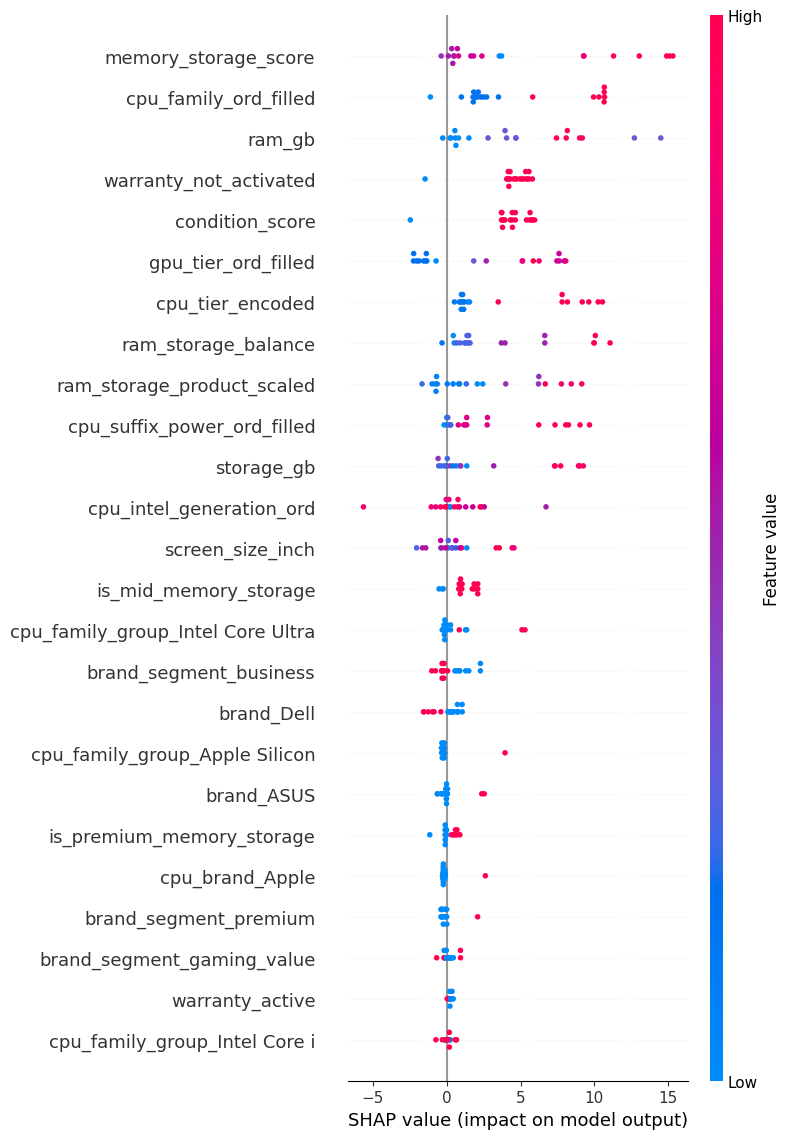

Saved SHAP top error plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_error_analysis\plots\shap_top_error_cases.png
Saved SHAP top error feature importance to: Y:\Python\Laptop-Price-Prediction\reports\error_analysis\shap_top_error_feature_importance.csv


In [24]:
shap_top_error_success = False
shap_top_error_path = ERROR_PLOT_DIR / "shap_top_error_cases.png"
shap_importance_path = ERROR_ANALYSIS_REPORT_DIR / "shap_top_error_feature_importance.csv"

try:
    import shap

    evaluation_model_path = EVAL_MODEL_DIR / "selected_evaluation_model.joblib"

    if not evaluation_model_path.exists():
        raise FileNotFoundError(
            f"Missing evaluation model artifact: {evaluation_model_path}"
        )

    evaluation_model = joblib.load(evaluation_model_path)

    top_sample_indices = top_error_cases_df["sample_index"].head(20).astype(int).tolist()
    X_top_errors_shap = X.loc[top_sample_indices].copy()

    explainer = shap.TreeExplainer(evaluation_model)
    shap_values = explainer.shap_values(X_top_errors_shap)

    if isinstance(shap_values, list):
        shap_values_for_table = shap_values[0]
    else:
        shap_values_for_table = shap_values

    shap_importance_top_errors = pd.DataFrame({
        "feature": X_top_errors_shap.columns,
        "mean_abs_shap": np.abs(shap_values_for_table).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)

    display(shap_importance_top_errors.head(30))
    shap_importance_top_errors.to_csv(shap_importance_path, index=False)

    shap.summary_plot(
        shap_values,
        X_top_errors_shap,
        max_display=25,
        show=False,
    )

    plt.tight_layout()
    plt.savefig(shap_top_error_path, dpi=150, bbox_inches="tight")
    plt.show()

    shap_top_error_success = True
    print(f"Saved SHAP top error plot to: {shap_top_error_path}")
    print(f"Saved SHAP top error feature importance to: {shap_importance_path}")

except Exception as e:
    print(f"Warning: SHAP top error analysis skipped due to error: {e}")

## SHAP Top Error Cases Interpretation

Biểu đồ SHAP trên giải thích các feature có ảnh hưởng lớn nhất đến dự đoán của model trong nhóm top error cases. Đây không phải là feature importance trên toàn bộ holdout, mà chỉ tập trung vào các dòng có lỗi cao nhất. Vì vậy, kết quả này dùng để hiểu vì sao model sai ở các case khó.

Trong SHAP plot:

```text id="2c9wij"
SHAP value > 0 → feature đẩy predicted_price tăng lên
SHAP value < 0 → feature kéo predicted_price giảm xuống
```

Màu của điểm thể hiện giá trị feature:

```text id="ibrv46"
đỏ/hồng → giá trị feature cao
xanh    → giá trị feature thấp
```

### Main important features

Các feature có `mean_abs_shap` cao nhất trong nhóm lỗi lớn là:

```text id="gk7yu3"
memory_storage_score          = 5.2521
cpu_family_ord_filled         = 4.7672
ram_gb                        = 4.7032
warranty_not_activated        = 4.6536
condition_score               = 4.5043
gpu_tier_ord_filled           = 4.0183
cpu_tier_encoded              = 3.9855
ram_storage_balance           = 3.7330
ram_storage_product_scaled    = 3.0982
cpu_suffix_power_ord_filled   = 3.0476
storage_gb                    = 2.9460
```

Điều này cho thấy các case lỗi cao chủ yếu bị chi phối bởi nhóm feature liên quan đến cấu hình phần cứng, đặc biệt là RAM/storage, CPU, GPU, warranty và condition.

### Memory and storage features dominate top errors

Feature quan trọng nhất là `memory_storage_score`, với `mean_abs_shap = 5.2521`. Ngoài ra, các feature liên quan như `ram_gb`, `storage_gb`, `ram_storage_balance`, `ram_storage_product_scaled`, `is_mid_memory_storage`, và `is_premium_memory_storage` cũng xuất hiện trong top SHAP features.

Điều này khớp với các phân tích trước: nhóm lỗi cao thường liên quan đến các laptop có RAM/storage lớn hoặc cấu hình memory-storage bất thường. Tuy nhiên, RAM/storage không giải thích giá theo quan hệ tuyến tính đơn giản. Một máy có RAM/storage cao vẫn có thể rẻ hơn kỳ vọng nếu CPU/GPU yếu, đời máy cũ, condition thấp hoặc brand/series không premium. Ngược lại, một máy có RAM/storage không quá cao vẫn có thể đắt nếu thuộc dòng flagship hoặc có GPU/CPU mạnh.

### CPU and GPU features are also major drivers

Các feature CPU/GPU có ảnh hưởng lớn gồm:

```text id="11g21b"
cpu_family_ord_filled
cpu_tier_encoded
cpu_suffix_power_ord_filled
cpu_intel_generation_ord
cpu_family_group_Intel Core Ultra
gpu_tier_ord_filled
```

Trong plot, các giá trị feature cao thường có SHAP value dương, nghĩa là chúng đẩy dự đoán giá lên. Điều này hợp lý vì CPU/GPU mạnh hơn thường làm giá laptop tăng.

Tuy nhiên, trong top error cases, việc các feature này có SHAP lớn cũng cho thấy model có thể đang phụ thuộc mạnh vào cấu hình CPU/GPU. Nếu CPU/GPU nhìn “cao cấp” nhưng thực tế máy thuộc dòng cũ, condition thấp hoặc giá thị trường thấp hơn kỳ vọng, model dễ overpredict. Ngược lại, nếu feature CPU/GPU không capture đủ dòng máy premium, model có thể underpredict.

### Warranty and condition strongly affect error cases

`warranty_not_activated` và `condition_score` đều có `mean_abs_shap` rất cao:

```text id="06myh8"
warranty_not_activated = 4.6536
condition_score        = 4.5043
```

Điều này cho thấy các thông tin về tình trạng máy và bảo hành ảnh hưởng mạnh trong nhóm lỗi cao. `warranty_not_activated` thường là tín hiệu của máy mới hoặc gần như mới, nên model có xu hướng tăng giá dự đoán. `condition_score` cao cũng thường làm model tăng predicted price.

Tuy nhiên, nếu các tín hiệu này không đi kèm với đúng brand/model/series hoặc cấu hình thật sự cao cấp, model có thể dự đoán quá cao. Ngược lại, nếu một máy thật sự premium nhưng warranty/condition không đủ thể hiện giá trị, model có thể dự đoán thấp.

### Brand and segment features have smaller SHAP impact

Các feature brand/segment như `brand_segment_business`, `brand_Dell`, `brand_ASUS`, `brand_segment_premium`, `brand_segment_gaming_value`, `brand_Lenovo` có `mean_abs_shap` thấp hơn nhiều so với nhóm RAM/storage và CPU/GPU.

Điều này cho thấy trong nhóm lỗi cao, model đang dựa nhiều hơn vào cấu hình phần cứng và ít hơn vào brand/product-line. Đây có thể là một hạn chế, vì giá laptop thực tế phụ thuộc rất mạnh vào series hoặc product line. Ví dụ hai máy có cùng RAM, storage và CPU nhưng thuộc hai dòng khác nhau vẫn có thể chênh lệch giá lớn.

Do đó, nếu dữ liệu gốc cho phép, nên cải thiện feature về `model`, `series`, `product line`, hoặc brand-tier cụ thể hơn thay vì chỉ dựa vào brand one-hot hoặc brand segment tổng quát.

### Main takeaway

SHAP analysis cho thấy các lỗi lớn không phải ngẫu nhiên. Model đang bị chi phối mạnh bởi các feature cấu hình như RAM/storage, CPU, GPU, warranty và condition. Những feature này có tác động hợp lý về mặt domain, nhưng ở các case đặc biệt chúng chưa đủ để giải thích giá thực tế.

Hướng cải thiện tiếp theo nên tập trung vào:

* Bổ sung hoặc làm sạch thông tin `model` / `series`.
* Tạo thêm interaction giữa RAM/storage, CPU tier, GPU tier, warranty và brand segment.
* Kiểm tra riêng các case `warranty_not_activated = 1`.
* Kiểm tra riêng các case CPU/GPU tier cao nhưng giá thực tế thấp để phát hiện overprediction.
* Kiểm tra các case giá cao nhưng model underpredict để tìm tín hiệu premium bị thiếu.
* Tăng khả năng phân biệt product line thay vì chỉ dựa vào cấu hình phần cứng.

Tóm lại, SHAP xác nhận rằng model đã học đúng các tín hiệu quan trọng, nhưng các top error cases thường nằm ở những trường hợp mà cấu hình phần cứng không đủ đại diện cho giá trị thật của laptop.


## Learning Curve Analysis Before Full-data Retraining

Section này kiểm tra model final có đang bị giới hạn bởi data size, model capacity, hoặc chất lượng feature hay không.

Learning curve so sánh train RMSE và validation RMSE khi tăng số lượng training samples. Phần này chạy trước full-data retraining và chỉ dùng `X_train` / `y_train`, không dùng full `X` / `y`.

Diễn giải cần thận trọng:

- Nếu train RMSE thấp hơn validation RMSE, model có generalization gap và có thể có dấu hiệu overfitting nhẹ/trung bình.
- Nếu validation RMSE vẫn giảm khi training size tăng, thêm dữ liệu vẫn có khả năng hữu ích.
- Nếu validation RMSE plateau, bottleneck có thể đến từ feature quality hoặc capacity hiện tại.
- Kết quả learning curve là diagnostic, không dùng để chọn lại model trong notebook này.

Learning curve cho thấy vẫn còn generalization gap giữa train RMSE và validation RMSE, nên model có thể còn overfit ở một mức nào đó. Tuy nhiên nếu validation RMSE vẫn cải thiện khi tăng training size, thêm dữ liệu hoặc cải thiện feature cho các nhóm khó như laptop giá cao có thể tiếp tục giúp model tốt hơn.

In [25]:
candidate_model_paths = {
    "LightGBM_baseline": TUNING_MODEL_DIR / "lightgbm_target_price_baseline.pkl",
    "LightGBM_tuned": TUNING_MODEL_DIR / "lightgbm_target_price_tuned.pkl",
    "CatBoost_baseline": TUNING_MODEL_DIR / "catboost_target_price_baseline.pkl",
    "CatBoost_tuned": TUNING_MODEL_DIR / "catboost_target_price_tuned.pkl",
}

candidate_models = {}

for label, path in candidate_model_paths.items():
    if path.exists():
        candidate_models[label] = joblib.load(path)

In [26]:
best_holdout_label = final_decision.get("best_holdout_model")

learning_curve_candidates = {}

if recommended_model_label in candidate_models:
    learning_curve_candidates[recommended_model_label] = candidate_models[recommended_model_label]
else:
    raise ValueError(f"Recommended model not found in candidate_models: {recommended_model_label}")

if best_holdout_label is not None and best_holdout_label in candidate_models:
    learning_curve_candidates[best_holdout_label] = candidate_models[best_holdout_label]

print("Learning curve candidates:")
print(list(learning_curve_candidates.keys()))

Learning curve candidates:
['CatBoost_tuned', 'LightGBM_baseline']


In [27]:
price_segment_learning = pd.qcut(
    y_train,
    q=5,
    labels=False,
    duplicates="drop",
)

learning_cv = list(
    StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    ).split(X_train, price_segment_learning)
)

In [28]:
train_sizes = np.linspace(0.2, 1.0, 5)

learning_curve_rows = []

for model_label, model in learning_curve_candidates.items():
    print(f"Running learning curve for: {model_label}")

    train_sizes_abs, train_scores, valid_scores = learning_curve(
        estimator=clone(model),
        X=X_train,
        y=y_train,
        train_sizes=train_sizes,
        cv=learning_cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        shuffle=False,
    )

    train_rmse = -train_scores
    valid_rmse = -valid_scores

    for i, train_size in enumerate(train_sizes_abs):
        learning_curve_rows.append({
            "model_label": model_label,
            "train_size": int(train_size),
            "train_rmse_mean": train_rmse[i].mean(),
            "train_rmse_std": train_rmse[i].std(),
            "valid_rmse_mean": valid_rmse[i].mean(),
            "valid_rmse_std": valid_rmse[i].std(),
            "generalization_gap": valid_rmse[i].mean() - train_rmse[i].mean(),
        })

learning_curve_df = pd.DataFrame(learning_curve_rows)

display(learning_curve_df)

learning_curve_df.to_csv(
    ERROR_METRIC_DIR / "learning_curve_summary.csv",
    index=False,
)

Running learning curve for: CatBoost_tuned
Running learning curve for: LightGBM_baseline


,model_label,train_size,train_rmse_mean,train_rmse_std,valid_rmse_mean,valid_rmse_std,generalization_gap
0,CatBoost_tuned,933,1.863714,0.121864,6.534291,0.314787,4.670577
1,CatBoost_tuned,1867,2.382218,0.055877,5.794816,0.182637,3.412597
2,CatBoost_tuned,2800,2.595685,0.071810,5.447185,0.300087,2.851500
3,CatBoost_tuned,3734,2.830802,0.050249,5.365225,0.322939,2.534423
4,CatBoost_tuned,4668,3.041770,0.062992,5.243180,0.213832,2.201410
5,LightGBM_baseline,933,3.255800,0.191206,6.983259,0.191733,3.727458
6,LightGBM_baseline,1867,3.456952,0.076351,6.070962,0.208600,2.614010
7,LightGBM_baseline,2800,3.303009,0.049632,5.687868,0.220815,2.384859
8,LightGBM_baseline,3734,3.417568,0.060625,5.539742,0.229224,2.122174
9,LightGBM_baseline,4668,3.506772,0.054832,5.476343,0.283746,1.969571


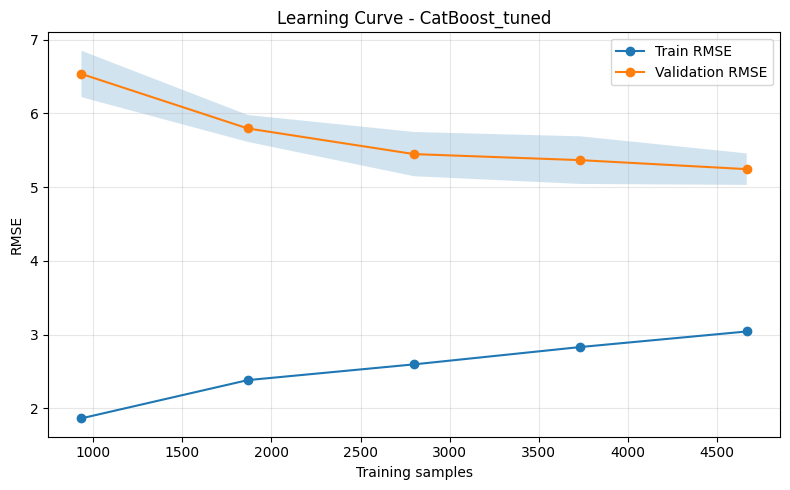

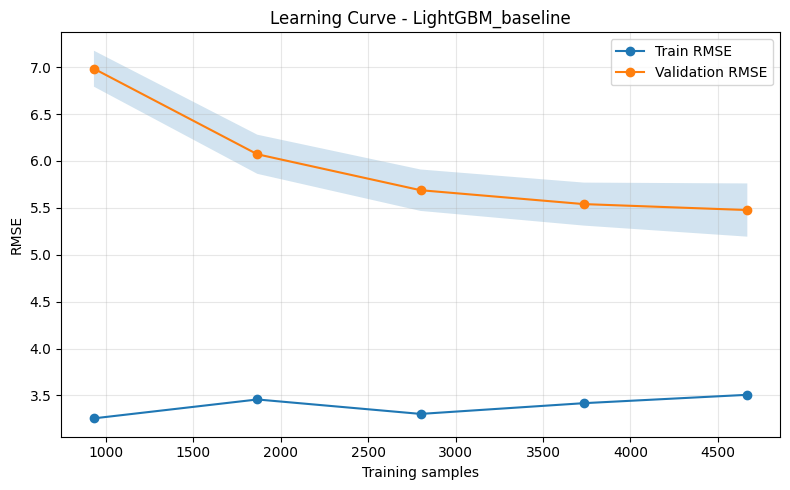

In [29]:
def safe_filename(label):
    return "".join(ch if ch.isalnum() or ch in ["-", "_"] else "_" for ch in str(label))


def plot_learning_curve(learning_curve_df, model_label):
    plot_df = learning_curve_df[
        learning_curve_df["model_label"] == model_label
    ].copy()

    plt.figure(figsize=(8, 5))

    plt.plot(
        plot_df["train_size"],
        plot_df["train_rmse_mean"],
        marker="o",
        label="Train RMSE",
    )

    plt.plot(
        plot_df["train_size"],
        plot_df["valid_rmse_mean"],
        marker="o",
        label="Validation RMSE",
    )

    plt.fill_between(
        plot_df["train_size"],
        plot_df["valid_rmse_mean"] - plot_df["valid_rmse_std"],
        plot_df["valid_rmse_mean"] + plot_df["valid_rmse_std"],
        alpha=0.2,
    )

    plt.title(f"Learning Curve - {model_label}")
    plt.xlabel("Training samples")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    path = ERROR_PLOT_DIR / f"learning_curve_{safe_filename(model_label)}.png"
    plt.savefig(path, dpi=150)
    plt.show()


for model_label in learning_curve_df["model_label"].unique():
    plot_learning_curve(learning_curve_df, model_label)

## Learning Curve Interpretation

Learning curve được dùng để kiểm tra model còn hưởng lợi từ việc tăng dữ liệu hay không, đồng thời đánh giá mức độ chênh lệch giữa lỗi trên train và lỗi trên validation.

Ở cả hai model, validation RMSE đều giảm khi số lượng training samples tăng. Điều này cho thấy thêm dữ liệu vẫn có khả năng giúp model cải thiện generalization.

### CatBoost tuned

Với `CatBoost_tuned`, validation RMSE giảm khá rõ khi tăng training size:

```text id="la39lz"
train_size = 933   → valid RMSE = 6.5343
train_size = 1867  → valid RMSE = 5.7948
train_size = 2800  → valid RMSE = 5.4472
train_size = 3734  → valid RMSE = 5.3652
train_size = 4668  → valid RMSE = 5.2432
```

Generalization gap cũng giảm dần:

```text id="6kxfqq"
gap = 4.6706 → 3.4126 → 2.8515 → 2.5344 → 2.2014
```

Điều này là tín hiệu tốt. Khi dữ liệu tăng, model không chỉ có validation RMSE thấp hơn mà khoảng cách train-validation cũng thu hẹp lại. Tuy nhiên, gap cuối cùng vẫn còn khoảng `2.20`, nghĩa là model vẫn có dấu hiệu overfitting nhẹ/trung bình hoặc vẫn chưa generalize hoàn toàn tốt với các case khó.

Một điểm đáng chú ý là train RMSE tăng khi train size tăng. Điều này bình thường trong learning curve: khi có nhiều dữ liệu hơn, training set đa dạng và khó hơn, nên model không còn fit quá sát các sample nhỏ ban đầu. Ngược lại, validation RMSE giảm cho thấy khả năng tổng quát hóa tốt hơn.

### LightGBM baseline

Với `LightGBM_baseline`, validation RMSE cũng giảm khi tăng training size:

```text id="atw8g7"
train_size = 933   → valid RMSE = 6.9833
train_size = 1867  → valid RMSE = 6.0710
train_size = 2800  → valid RMSE = 5.6879
train_size = 3734  → valid RMSE = 5.5397
train_size = 4668  → valid RMSE = 5.4763
```

Generalization gap cũng giảm:

```text id="bkv5h0"
gap = 3.7275 → 2.6140 → 2.3849 → 2.1222 → 1.9696
```

LightGBM có gap cuối thấp hơn CatBoost, nhưng validation RMSE cuối vẫn cao hơn CatBoost:

```text id="mjr7a4"
CatBoost_tuned final valid RMSE   = 5.2432
LightGBM_baseline final valid RMSE = 5.4763
```

Điều này cho thấy trong learning curve này, `CatBoost_tuned` vẫn có validation performance tốt hơn, dù generalization gap lớn hơn một chút.

### Model comparison

So sánh hai model ở training size lớn nhất:

```text id="fuab5j"
CatBoost_tuned:
train RMSE = 3.0418
valid RMSE = 5.2432
gap        = 2.2014

LightGBM_baseline:
train RMSE = 3.5068
valid RMSE = 5.4763
gap        = 1.9696
```

`CatBoost_tuned` fit training data tốt hơn và đạt validation RMSE thấp hơn. Tuy nhiên, gap của CatBoost lớn hơn, nên cần ghi nhận rằng model này có xu hướng fit mạnh hơn LightGBM. Đây không phải là overfitting nghiêm trọng, vì validation RMSE vẫn giảm khi tăng dữ liệu, nhưng vẫn là dấu hiệu cần theo dõi.

### Main takeaway

Learning curve cho thấy cả hai model vẫn có thể được cải thiện nếu có thêm dữ liệu. Validation RMSE chưa hoàn toàn plateau, đặc biệt là ở `CatBoost_tuned`, nên việc bổ sung dữ liệu mới hoặc cải thiện feature engineering vẫn có ý nghĩa.

Kết quả này cũng ủng hộ quyết định giữ `CatBoost_tuned` làm final model: model này có validation RMSE tốt hơn trong learning curve và vẫn tiếp tục cải thiện khi tăng training size. Tuy nhiên, cần lưu ý rằng generalization gap vẫn còn, nên hướng cải thiện tiếp theo nên tập trung vào:

* Bổ sung dữ liệu cho nhóm laptop giá cao và cấu hình hiếm.
* Làm sạch thêm các feature về model/series/product line.
* Giảm các feature thiếu thông tin như `no_info_model`, `no_info_cpu_tier`, `no_info_brand`.
* Kiểm soát overfitting nhẹ bằng regularization hoặc tuning nếu tiếp tục phát triển model.
* Kiểm tra riêng các nhóm high-error đã phát hiện ở các section trước.

Tóm lại, learning curve cho thấy model chưa bị “hết đường cải thiện”. Thêm dữ liệu và cải thiện feature vẫn là hướng hợp lý hơn so với chỉ tiếp tục tuning hyperparameter.


In [30]:
learning_curve_interpretation_rows = []

for model_label in learning_curve_df["model_label"].unique():
    model_lc = learning_curve_df[
        learning_curve_df["model_label"] == model_label
    ].sort_values("train_size")

    first_row = model_lc.iloc[0]
    last_row = model_lc.iloc[-1]

    valid_improvement = (
        first_row["valid_rmse_mean"] - last_row["valid_rmse_mean"]
    )

    valid_improvement_pct = (
        valid_improvement / first_row["valid_rmse_mean"] * 100
    )

    final_gap = last_row["generalization_gap"]

    if final_gap > 1.0:
        fit_status = "possible_overfitting"
    elif last_row["valid_rmse_mean"] > 6.0 and final_gap < 0.5:
        fit_status = "possible_underfitting"
    else:
        fit_status = "reasonable_fit"

    if valid_improvement_pct > 5:
        data_status = "more_data_may_help"
    else:
        data_status = "validation_curve_mostly_plateaued"

    learning_curve_interpretation_rows.append({
        "model_label": model_label,
        "first_valid_rmse": first_row["valid_rmse_mean"],
        "last_valid_rmse": last_row["valid_rmse_mean"],
        "valid_rmse_improvement": valid_improvement,
        "valid_rmse_improvement_pct": valid_improvement_pct,
        "final_train_rmse": last_row["train_rmse_mean"],
        "final_valid_rmse": last_row["valid_rmse_mean"],
        "final_generalization_gap": final_gap,
        "fit_status": fit_status,
        "data_status": data_status,
    })

learning_curve_interpretation_df = pd.DataFrame(
    learning_curve_interpretation_rows
)

display(learning_curve_interpretation_df)

learning_curve_interpretation_df.to_csv(
    ERROR_REPORT_DIR / "learning_curve_interpretation.csv",
    index=False,
)

,model_label,first_valid_rmse,last_valid_rmse,valid_rmse_improvement,valid_rmse_improvement_pct,final_train_rmse,final_valid_rmse,final_generalization_gap,fit_status,data_status
0,CatBoost_tuned,6.534291,5.243180,1.291112,19.759014,3.041770,5.243180,2.201410,possible_overfitting,more_data_may_help
1,LightGBM_baseline,6.983259,5.476343,1.506916,21.578981,3.506772,5.476343,1.969571,possible_overfitting,more_data_may_help


## Learning Curve Summary Interpretation

Bảng summary trên tóm tắt mức cải thiện của validation RMSE khi tăng training size, đồng thời đánh giá generalization gap ở training size lớn nhất.

Cả hai model đều có `data_status = more_data_may_help`, nghĩa là validation RMSE vẫn giảm khi có thêm dữ liệu. Điều này cho thấy hiệu năng model chưa hoàn toàn bão hòa, và việc bổ sung thêm dữ liệu vẫn có khả năng cải thiện kết quả.

### CatBoost tuned

`CatBoost_tuned` giảm validation RMSE từ `6.5343` xuống `5.2432`:

```text id="8zv8iq"
valid_rmse_improvement     = 1.2911
valid_rmse_improvement_pct = 19.76%
```

Đây là mức cải thiện khá rõ khi tăng training size. Ở training size cuối, model có:

```text id="w0jkfk"
final_train_rmse = 3.0418
final_valid_rmse = 5.2432
final_gap        = 2.2014
```

Gap này cho thấy model vẫn fit train tốt hơn validation khá nhiều, nên được gắn nhãn `possible_overfitting`. Tuy nhiên, vì validation RMSE vẫn tiếp tục giảm khi tăng dữ liệu, đây nên được hiểu là **generalization gap còn tồn tại**, không phải overfitting nghiêm trọng.

### LightGBM baseline

`LightGBM_baseline` giảm validation RMSE từ `6.9833` xuống `5.4763`:

```text id="h7fg8f"
valid_rmse_improvement     = 1.5069
valid_rmse_improvement_pct = 21.58%
```

Tỷ lệ cải thiện của LightGBM cao hơn CatBoost một chút, nhưng validation RMSE cuối vẫn cao hơn:

```text id="x1r5qv"
CatBoost_tuned final valid RMSE   = 5.2432
LightGBM_baseline final valid RMSE = 5.4763
```

Ở training size cuối, LightGBM có generalization gap thấp hơn:

```text id="jpc6sj"
LightGBM final gap = 1.9696
CatBoost final gap = 2.2014
```

Điều này cho thấy LightGBM generalize “mềm” hơn một chút, nhưng đổi lại performance validation cuối chưa tốt bằng CatBoost.

### Model comparison

Kết quả summary cho thấy hai điểm chính:

```text id="7qquka"
CatBoost_tuned có final validation RMSE thấp hơn.
LightGBM_baseline có improvement_pct cao hơn và final gap thấp hơn.
```

Vì mục tiêu cuối cùng là chọn model có performance tốt và ổn định theo quyết định từ notebook 14, kết quả learning curve vẫn ủng hộ việc giữ `CatBoost_tuned` làm final production model. CatBoost có gap lớn hơn nhẹ, nhưng validation RMSE cuối tốt hơn và vẫn cải thiện khi tăng dữ liệu.

### Main takeaway

Cả hai model đều chưa hoàn toàn đạt trạng thái plateau. Do đó, nếu tiếp tục cải thiện sau notebook 15, hướng ưu tiên nên là:

* Bổ sung thêm dữ liệu, đặc biệt cho laptop giá cao và cấu hình hiếm.
* Cải thiện feature cho model/series/product line.
* Giảm các trường hợp thiếu thông tin như `no_info_model`, `no_info_cpu_tier`, `no_info_brand`.
* Kiểm tra riêng các nhóm high-error đã phát hiện qua residual, SHAP và feature-frequency analysis.
* Chỉ tuning thêm hyperparameter sau khi đã cải thiện dữ liệu và feature.

Tóm lại, learning curve summary cho thấy model còn dư địa cải thiện. `CatBoost_tuned` vẫn là lựa chọn production hợp lý, nhưng generalization gap cho thấy hướng cải thiện tiếp theo nên tập trung vào dữ liệu và feature engineering hơn là chỉ tiếp tục tinh chỉnh tham số.


## Final Error Interpretation

Error analysis cho thấy model final `CatBoost_tuned` không có bias toàn cục quá lớn. Mean residual chỉ khoảng `-0.0644`, nghĩa là trung bình model hơi overpredict nhẹ, nhưng mức lệch này rất nhỏ so với sai số tổng thể.

Tuy nhiên, lỗi không phân bố đều giữa các phân khúc giá. Phân khúc có RMSE cao nhất là `Q5_high`, với RMSE khoảng `11.27`. Điều này cho thấy nhóm laptop giá cao vẫn là vùng khó nhất của model. Đây thường là nhóm có cấu hình mạnh, nhiều biến thể premium, brand/model đặc thù, RAM/storage lớn, GPU/CPU cao cấp hoặc các mẫu máy hiếm. Vì vậy, nếu tiếp tục cải thiện model, nên ưu tiên phân tích và bổ sung feature cho nhóm giá cao trước.

Về hướng sai số, toàn bộ holdout có `665` case underprediction và `795` case overprediction. Điều này cho thấy model hơi nghiêng về overprediction, nhưng không nghiêm trọng. Trong nhóm lỗi cao nhất, underprediction và overprediction vẫn cùng xuất hiện nhiều, nên vấn đề chính không phải là model luôn dự đoán lệch theo một chiều, mà là model gặp khó ở các outlier hoặc các cấu hình đặc biệt.

High-error audit cho thấy nhiều case lỗi lớn có các feature như `no_info_model`, `warranty_not_activated`, `is_mid_memory_storage`, `is_premium_memory_storage`, `cpu_brand_Intel`, `gpu_tier_ord_filled`, hoặc các nhóm CPU/brand sparse. Điều này gợi ý rằng model vẫn thiếu khả năng phân biệt một số dòng máy cụ thể, nhất là khi thông tin model/series không đầy đủ hoặc các feature cấu hình chưa đủ mô tả đúng phân khúc sản phẩm.

Các file full feature audit đã được export để kiểm tra thủ công từng case lỗi cao. Đây là phần quan trọng vì file compact chỉ giúp xem nhanh các feature khác 0, còn file full audit chứa toàn bộ feature đầu vào của model, bao gồm one-hot, sparse feature, CPU/GPU feature, brand feature, warranty/condition và các interaction feature. Nhờ đó có thể soi lại từng dòng lỗi lớn để phát hiện pattern lặp lại hoặc feature bị thiếu thông tin.

Learning curve cho thấy model còn generalization gap, với trạng thái `possible_overfitting`, nhưng đồng thời `data_status = more_data_may_help`. Điều này nghĩa là model vẫn có khả năng cải thiện nếu có thêm dữ liệu hoặc feature tốt hơn, đặc biệt ở các nhóm khó như laptop giá cao và các cấu hình hiếm.

Tóm lại, model đã đủ ổn để export production, nhưng hướng cải thiện tiếp theo nên tập trung vào:

* Làm sạch và bổ sung thông tin model/series.
* Cải thiện feature cho laptop premium và phân khúc `Q5_high`.
* Kiểm tra kỹ các case RAM/storage rất cao hoặc bất thường.
* Phân tích riêng các case `no_info_model` và các brand/CPU/GPU sparse.
* Dùng các file full feature audit để soi thủ công những dòng có sai số lớn nhất.


In [31]:
highest_segment_error = price_segment_error_df.sort_values(
    "rmse",
    ascending=False,
).iloc[0]

learning_curve_key = learning_curve_interpretation_df[
    learning_curve_interpretation_df["model_label"] == recommended_model_label
].iloc[0]

final_error_summary = {
    "model_label": recommended_model_label,
    "highest_error_price_segment": highest_segment_error["price_segment"],
    "highest_segment_rmse": float(highest_segment_error["rmse"]),
    "mean_residual": float(error_overview_df.iloc[0]["mean_residual"]),
    "underprediction_count": int(error_overview_df.iloc[0]["underprediction_count"]),
    "overprediction_count": int(error_overview_df.iloc[0]["overprediction_count"]),
    "learning_curve_fit_status": learning_curve_key["fit_status"],
    "learning_curve_data_status": learning_curve_key["data_status"],
}

final_error_summary_df = pd.DataFrame([final_error_summary])
display(final_error_summary_df)

final_error_summary_df.to_csv(
    ERROR_REPORT_DIR / "final_error_summary.csv",
    index=False,
)

with open(ERROR_REPORT_DIR / "final_error_summary.json", "w", encoding="utf-8") as f:
    json.dump(final_error_summary, f, indent=2, ensure_ascii=False)

,model_label,highest_error_price_segment,highest_segment_rmse,mean_residual,underprediction_count,overprediction_count,learning_curve_fit_status,learning_curve_data_status
0,CatBoost_tuned,Q5_high,11.267712,-0.064396,665,795,possible_overfitting,more_data_may_help


## Retrain Finalized Model Configuration on 100% Data

The model evaluated in notebook 14 was trained on the 80% training split so that the 20% holdout set could be used for unbiased evaluation.

After evaluation and error analysis are complete, the final selected model configuration is retrained on 100% of the available labeled dataset.

There is no new holdout evaluation after this step. The evaluation references remain notebook 13 KFold results and notebook 14 holdout results.

In [32]:
evaluation_model_path = EVAL_MODEL_DIR / "selected_evaluation_model.joblib"

if not evaluation_model_path.exists():
    raise FileNotFoundError(f"Missing evaluation model artifact: {evaluation_model_path}")

evaluated_model = joblib.load(evaluation_model_path)

final_full_model = clone(evaluated_model)
final_full_model.fit(X, y)

print("Final full-data model trained.")

Final full-data model trained.


## Export Production Model to Root `models/`

In [33]:
full_model_path = PRODUCTION_MODEL_DIR / "final_laptop_price_model.joblib"
full_model_archive_path = PRODUCTION_MODEL_DIR / "final_laptop_price_model_full_data.joblib"
metadata_path = PRODUCTION_MODEL_DIR / "final_laptop_price_model_metadata.json"
schema_path = PRODUCTION_MODEL_DIR / "final_laptop_price_feature_schema.json"

joblib.dump(final_full_model, full_model_path)
joblib.dump(final_full_model, full_model_archive_path)

production_metadata = {
    "model_file": str(full_model_path),
    "archived_full_data_model_file": str(full_model_archive_path),
    "model_label": recommended_model_label,
    "target": TARGET_COL,
    "prediction_unit": "same_unit_as_target_price",
    "training_scope": "full_dataset_100_percent",
    "n_training_samples": int(len(X)),
    "n_features": int(X.shape[1]),
    "feature_order_file": str(schema_path),
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "source_notebook": "15_final_error_analysis_and_production_retrain.ipynb",
    "evaluation_reference": "notebook_13_kfold_and_notebook_14_holdout",
    "warning": (
        "This production model is retrained on 100% of labeled data. "
        "Its reported evaluation metrics come from notebook 13 KFold selection "
        "and notebook 14 holdout evaluation, not from a new holdout after full-data retraining."
    ),
    "final_decision": final_decision,
    "final_error_summary": final_error_summary,
}

feature_schema = {
    "target": TARGET_COL,
    "n_features": len(feature_names),
    "feature_names": feature_names,
    "feature_order_required": True,
    "input_format": "pandas.DataFrame",
    "missing_feature_policy": "raise_error",
    "extra_feature_policy": "ignore_or_drop_before_prediction",
    "training_scope": "full_dataset_100_percent",
    "notes": (
        "Backend must provide the final engineered numeric feature matrix in this exact feature order. "
        "This model does not accept raw laptop fields directly unless the same preprocessing pipeline is applied first."
    ),
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(production_metadata, f, indent=2, ensure_ascii=False)

with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(feature_schema, f, indent=2, ensure_ascii=False)

print(f"Saved production model to: {full_model_path}")
print(f"Saved production metadata to: {metadata_path}")
print(f"Saved production feature schema to: {schema_path}")

Saved production model to: Y:\Python\Laptop-Price-Prediction\models\final_laptop_price_model.joblib
Saved production metadata to: Y:\Python\Laptop-Price-Prediction\models\final_laptop_price_model_metadata.json
Saved production feature schema to: Y:\Python\Laptop-Price-Prediction\models\final_laptop_price_feature_schema.json


## Production Smoke Test

In [34]:
def align_features_for_prediction(input_df, schema):
    required_features = schema["feature_names"]

    missing = [c for c in required_features if c not in input_df.columns]
    extra = [c for c in input_df.columns if c not in required_features]

    if missing:
        raise ValueError(f"Missing required features: {missing}")

    if extra:
        print(f"Warning: extra columns ignored: {extra[:20]}")
        if len(extra) > 20:
            print(f"... and {len(extra) - 20} more extra columns")

    return input_df[required_features].copy()

In [35]:
loaded_full_model = joblib.load(full_model_path)

with open(schema_path, "r", encoding="utf-8") as f:
    loaded_schema = json.load(f)

sample_X = X.iloc[:5].copy()
aligned_sample_X = align_features_for_prediction(sample_X, loaded_schema)
sample_pred = loaded_full_model.predict(aligned_sample_X)

smoke_test_df = pd.DataFrame({
    "sample_index": aligned_sample_X.index,
    "prediction": sample_pred,
})

display(smoke_test_df)

smoke_test_df.to_csv(
    ERROR_REPORT_DIR / "full_data_production_smoke_test_predictions.csv",
    index=False,
)

assert loaded_schema["feature_names"] == feature_names
assert len(loaded_schema["feature_names"]) == aligned_sample_X.shape[1]
assert aligned_sample_X.columns.tolist() == loaded_schema["feature_names"]

print("Full-data production model smoke test passed.")

,sample_index,prediction
0,0,8.881756
1,1,3.201738
2,2,6.167480
3,3,21.721625
4,4,10.932962


Full-data production model smoke test passed.


## Artifact Check

In [36]:
required_expected_files = [
    ERROR_PRED_DIR / "final_model_holdout_errors_with_context.csv",
    ERROR_PRED_DIR / "top_final_error_cases.csv",
    ERROR_PRED_DIR / "top_underprediction_cases.csv",
    ERROR_PRED_DIR / "top_overprediction_cases.csv",
    ERROR_PRED_DIR / "final_model_errors_with_explanation_tags.csv",
    ERROR_METRIC_DIR / "final_model_error_overview.csv",
    ERROR_METRIC_DIR / "error_by_price_segment.csv",
    ERROR_METRIC_DIR / "learning_curve_summary.csv",
    ERROR_REPORT_DIR / "learning_curve_interpretation.csv",
    ERROR_REPORT_DIR / "final_error_summary.csv",
    ERROR_REPORT_DIR / "final_error_summary.json",
    ERROR_REPORT_DIR / "full_data_production_smoke_test_predictions.csv",
    ERROR_ANALYSIS_REPORT_DIR / "high_error_cases_all_features_top_abs.csv",
    ERROR_ANALYSIS_REPORT_DIR / "high_error_cases_all_features_underprediction.csv",
    ERROR_ANALYSIS_REPORT_DIR / "high_error_cases_all_features_overprediction.csv",
    ERROR_ANALYSIS_REPORT_DIR / "high_error_cases_compact_top_abs.csv",
    ERROR_ANALYSIS_REPORT_DIR / "high_error_feature_frequency.csv",
    ERROR_ANALYSIS_REPORT_DIR / "prediction_error_tolerance_summary.csv",
    PRODUCTION_MODEL_DIR / "final_laptop_price_model.joblib",
    PRODUCTION_MODEL_DIR / "final_laptop_price_model_full_data.joblib",
    PRODUCTION_MODEL_DIR / "final_laptop_price_model_metadata.json",
    PRODUCTION_MODEL_DIR / "final_laptop_price_feature_schema.json",
]

for label in learning_curve_df["model_label"].unique():
    required_expected_files.append(ERROR_PLOT_DIR / f"learning_curve_{safe_filename(label)}.png")


for path in ram_storage_plot_paths:
    required_expected_files.append(path)

for path in tolerance_plot_paths:
    required_expected_files.append(path)

optional_expected_files = []
if shap_top_error_success:
    optional_expected_files.extend([
        ERROR_ANALYSIS_REPORT_DIR / "shap_top_error_feature_importance.csv",
        ERROR_PLOT_DIR / "shap_top_error_cases.png",
    ])
else:
    print("SHAP artifacts are optional and were skipped because SHAP did not complete successfully.")

artifact_rows = []

for path in required_expected_files:
    artifact_rows.append({
        "path": str(path),
        "required": True,
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
    })

for path in optional_expected_files:
    artifact_rows.append({
        "path": str(path),
        "required": False,
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
    })

for col in available_group_cols:
    path = ERROR_ANALYSIS_REPORT_DIR / f"error_by_{col}.csv"
    artifact_rows.append({
        "path": str(path),
        "required": False,
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
    })

artifact_check_df = pd.DataFrame(artifact_rows)
display(artifact_check_df)

missing_required = artifact_check_df[
    artifact_check_df["required"] & ~artifact_check_df["exists"]
]

if not missing_required.empty:
    raise FileNotFoundError(
        "Missing required expected artifacts:\n"
        + "\n".join(missing_required["path"].tolist())
    )

print("All required final error analysis and full-data production artifacts are present.")

,path,required,exists,size_bytes
0,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,True,172245
1,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,True,3690
2,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,True,3931
3,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,True,4469
4,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,True,278133
5,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,True,299
6,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,True,803
7,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,True,1278
8,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,True,546
9,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,True,283


All required final error analysis and full-data production artifacts are present.


## Final Conclusion

Notebook này hoàn tất final error analysis và production retrain.

Model cuối cùng vẫn là model được chọn từ notebook 14. Notebook 15 không chọn lại model mà chỉ dùng holdout để phân tích lỗi.

Error analysis cho thấy lỗi tập trung mạnh hơn ở nhóm laptop giá cao. Đây là vùng cần ưu tiên nếu tiếp tục cải thiện model.

Notebook đã bổ sung high-error case audit, trong đó toàn bộ feature của các case lỗi cao được export ra CSV. Điều này giúp kiểm tra thủ công các pattern lỗi, bao gồm feature sparse, one-hot, CPU/GPU, brand, condition, warranty và các interaction feature.

Notebook cũng bổ sung các biểu đồ actual-vs-predicted và residual theo `ram_gb` / `storage_gb`, bao gồm các phiên bản chỉ hiển thị điểm vượt ngưỡng sai lệch 5%, 10%, và 15%. Các biểu đồ này giúp quan sát sai lệch phân tán như thế nào khi RAM hoặc dung lượng lưu trữ thay đổi.

Learning curve cho thấy model vẫn còn generalization gap, nhưng validation performance vẫn có khả năng cải thiện khi tăng dữ liệu hoặc cải thiện feature ở các nhóm khó.

Cuối cùng, model được retrain trên 100% labeled data và export ra thư mục `models/`. Metric chính thức vẫn tham chiếu từ notebook 13/14 vì production model đã train lại trên toàn bộ dữ liệu.

Production model cho web/backend được lưu tại:

`models/final_laptop_price_model.joblib`

Backend cần dùng schema sau để align đúng thứ tự feature trước khi predict:

`models/final_laptop_price_feature_schema.json`